### Word-Masking Explanations for CNN and LSTM Intent Classifiers

In this notebook we are going to load INJONGO, prepare English (`eng`), isiXhosa (`xho`), isiZulu (`zul`) and Sesotho (`sot`) utterances, and train a separate CNN and LSTM for each language. All eight models start with randomly initialized, trainable word embeddings and model parameters. We are then going to investigate how individual words affect predictions. The analysis compares unknown-token replacement with deletion, evaluates important words against a random-word baseline, and examines whether the two methods identify similar words. Correct and incorrect predictions are analysed separately.

The research contribution is a systematic evaluation of token sensitivity and explanation agreement. Probability changes describe model behavior under a perturbation; they do not prove that an explanation is linguistically correct or causal. The default experiment uses one training seed, so operator agreement is not described as stability across training seeds.

In the following cells we are going to define the Python dependencies and experiment settings. The implementation uses standard PyTorch components compatible with supported Python 3.14 installations. Pigmenta supplies the nature palette. The commented package cell records the environment dependencies; package availability depends on the operating system and accelerator.


In [ ]:
# %pip install --upgrade --only-binary=:all: "torch>=2.10" numpy pandas matplotlib scikit-learn scipy pigmenta ipykernel

### Importing the packages
In the following cell we are going to import the tools for data handling, training, statistical summaries and visualization.


In [45]:
import sys, os, re, json, time, random, hashlib, unicodedata, platform
from pathlib import Path
from collections import Counter
from urllib.request import urlopen, Request
from urllib.error import HTTPError
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pigmenta import PALETTES
from cycler import cycler
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from IPython.display import display

from scipy.stats import spearmanr


### Defining the training configuration
In the following cell we are going to define shared hyperparameters and create a dedicated experiment folder. Cached dataset files may be reused, but model training always starts with new random weights.


In [46]:
LANGUAGES = {'eng': 'English', 'xho': 'isiXhosa', 'zul': 'isiZulu', 'sot': 'Sesotho'}
SEED = 17
CFG = dict(embedding_dim=128, hidden_dim=128, filters=128, kernels=[3, 4, 5],
           dropout=0.3, batch_size=64, epochs=25, patience=5, lr=0.001,
           weight_decay=0.0001, max_vocab=30000, min_freq=1, max_length_cap=128,
           validation_fraction=0.2, use_class_weights=True)
ROOT = Path('injongo_explanations_independent')
MODEL_DIR = ROOT / 'models'
OUT = MODEL_DIR; OUT.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / 'data'; CACHE.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Defining reproducibility settings
In the following cell we are going to define the random-seed settings used by both architectures. Hardware differences can still produce small numerical differences.


In [47]:
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### Recording the environment
In the following cell we are going to initialize the seed and save the training configuration and package versions.

In [48]:
seed_everything()
versions = {'python': sys.version, 'torch': torch.__version__, 'numpy': np.__version__,
            'pandas': pd.__version__, 'platform': platform.platform(), 'device': str(DEVICE)}
print(versions)
print('Seeds reduce variability; bitwise agreement across hardware is not guaranteed.')
(OUT / 'configuration.json').write_text(json.dumps({'config': CFG, 'seed': SEED, 'versions': versions}, indent=2))


{'python': '3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]', 'torch': '2.9.0+cu126', 'numpy': '2.4.6', 'pandas': '2.3.3', 'platform': 'Windows-11-10.0.26200-SP0', 'device': 'cuda'}
Seeds reduce variability; bitwise agreement across hardware is not guaranteed.


668

### Defining explanation settings
In the following cell we are going to set the sample size, perturbation budgets and random baseline repetitions. The default uses up to five utterances per intent, selected without looking at model predictions. A value of `None` represents all eligible utterances. 20 random orders are averaged within each example and are not independent observations.


In [49]:
MODEL_NAMES = ['CNN','LSTM']
PER_INTENT = 5
BUDGETS = [0.1,0.2,0.3,0.5]
RANDOM_REPEATS = 20
BOOTSTRAPS = 1000
INFERENCE_BATCH = 128


### Defining the nature palette
In the following cell we are going to use `PALETTES.nature` from Pigmenta for consistent plot colors. All figures use 120 dpi.


In [50]:
NATURE = list(PALETTES.nature)
MODEL_COLORS = {'CNN': NATURE[0], 'LSTM': NATURE[2]}
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120,
                     'figure.figsize': (9, 5), 'axes.grid': True,
                     'axes.axisbelow': True,
                     'axes.prop_cycle': cycler(color=NATURE),
                     'axes.spines.top': False, 'axes.spines.right': False})

RANK_COLORS = {'unk':NATURE[0], 'delete':NATURE[2], 'random':NATURE[6]}


### Formatting figures
In the following cell we are going to define the shared figure formatting. Related graphs are arranged in 3 columns, with solid major grids, dashed minor grids and legends below each graph in three columns. 


In [51]:
def finish(fig, filename):
    for ax in fig.axes:
        if not ax.get_visible(): continue
        ax.minorticks_on()
        ax.set_axisbelow(True)
        ax.grid(which='major',color='gray',linestyle='-',linewidth=0.5)
        ax.grid(which='minor',color='#7ED4AD',linestyle='--',linewidth=0.3)
        handles,labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5,-0.25),ncol=3)
    fig.tight_layout(h_pad=4,w_pad=2)
    fig.savefig(OUT / f'{filename}.png',dpi=120,bbox_inches='tight')
    plt.show()

def panels(count, height=4):
    rows = (count+2)//3
    fig,axes = plt.subplots(rows,3,figsize=(15,height*rows),squeeze=False)
    for ax in axes.flat[count:]: ax.set_visible(False)
    return fig,list(axes.flat[:count])


### Loading INJONGO
In the following cells we are going to download the JSONL files from the Masakhane INJONGO distribution. The loader recognizes utterance and intent fields, caches the downloaded files and records their hashes. English has no validation file in the published configuration, so its validation subset is constructed later from training data.

> https://huggingface.co/datasets/masakhane/InjongoIntent


In [52]:
REPO = 'masakhane/InjongoIntent'
REVISION = 'main'
manifest = []


In the following cell we are going to download or read cached records and calculate file hashes.

In [53]:
def read_jsonl(lang, filename, optional=False):
    path = CACHE / REVISION / lang / filename
    url = f'https://huggingface.co/datasets/{REPO}/resolve/{REVISION}/{lang}/{filename}'
    if not path.exists():
        try:
            with urlopen(Request(url, headers={'User-Agent': 'INJONGO-notebook'}), timeout=60) as response:
                data = response.read()
        except HTTPError as exc:
            if optional and exc.code == 404: return None
            raise
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(data)
    data = path.read_bytes()
    records = [json.loads(line) for line in data.decode('utf-8-sig').splitlines() if line.strip()]
    if not records or not all(isinstance(row, dict) for row in records):
        raise ValueError(f'{path}: expected nonempty JSON objects, one per line')
    manifest.append(dict(language=lang, file=filename, url=url, sha256=hashlib.sha256(data).hexdigest()))
    return pd.DataFrame.from_records(records)


In the following cell we are going to check the actual text and intent columns and report missing records.

In [56]:
def standardize(df, lang, split):
    text_col = next((k for k in ['text', 'raw', 'utterance', 'sentence'] if k in df), None)
    label_col = next((k for k in ['intent', 'label'] if k in df), None)
    if text_col is None or label_col is None:
        raise ValueError(f'{lang}/{split}: unsupported columns {list(df.columns)}')
    df = df[[text_col, label_col]].rename(columns={text_col: 'text', label_col: 'intent'}).copy()
    missing = df.isna().any(axis=1)
    print(lang, split, 'missing rows removed:', int(missing.sum()))
    df = df.loc[~missing].copy()
    if not df.text.map(lambda x: isinstance(x, str)).all():
        raise TypeError('Utterances must be strings; inspect source schema.')
    if not df.intent.map(lambda x: isinstance(x, (str, int, np.integer))).all():
        raise TypeError('Expected one scalar intent per utterance.')
    df['intent'] = df.intent.astype(str)
    df['source_row'] = df.index
    return df.reset_index(drop=True)


In the following cell we are going to collect the available training, validation and test files.

In [54]:
def load_language(lang):
    tables = {}
    for split, filename in [('train', 'train.jsonl'), ('validation', 'dev.jsonl'), ('test', 'test.jsonl')]:
        df = read_jsonl(lang, filename, optional=(lang == 'eng' and split == 'validation'))
        if df is not None: tables[split] = standardize(df, lang, split)
    return tables


In the following cell we are going to load each language and display the observed split sizes.

In [57]:
raw_data = {lang: load_language(lang) for lang in LANGUAGES}
(OUT / 'data_manifest.json').write_text(json.dumps(manifest, indent=2))
display(pd.DataFrame([dict(language=l, split=s, rows=len(d)) for l,t in raw_data.items() for s,d in t.items()]))
display(raw_data['eng']['train'].head())


eng train missing rows removed: 0
eng test missing rows removed: 0
xho train missing rows removed: 0
xho validation missing rows removed: 0
xho test missing rows removed: 0
zul train missing rows removed: 0
zul validation missing rows removed: 0
zul test missing rows removed: 0
sot train missing rows removed: 0
sot validation missing rows removed: 0
sot test missing rows removed: 0


,language,split,rows
0,eng,train,1779
1,eng,test,622
2,xho,train,2240
3,xho,validation,320
4,xho,test,640
5,zul,train,2240
6,zul,validation,320
7,zul,test,640
8,sot,train,2240
9,sot,validation,320


,text,intent,source_row
0,"how do I say ""I want to use the bus"" in Oromo ...",translate,0
1,Can you transfer 50000 birr from my commercial...,transfer,1
2,what time is it in Addis Ababa,time,2
3,Add teff to the groceries list.,shopping_list_update,3
4,Can you reserve a dinner place for me at Totot...,restaurant_reservation,4


### Cleaning and split preparation
In the following cells we are going to normalize Unicode text and whitespace while preserving numbers and accented characters. Training-only vocabulary construction prevents test information from influencing the representation. Official splits remain intact; missing or empty rows are removed and recorded. Exact-text overlaps are reported. Conflicting labels for identical normalized text stop processing for review. The English train/validation partition groups identical texts to prevent duplicate leakage between those two subsets.


In [58]:
def clean_text(text):
    return ' '.join(unicodedata.normalize('NFC', text).lower().split())
def tokenize(text):
    return re.findall(r"\w+(?:['’]\w+)*", clean_text(text), flags=re.UNICODE)


In the following cell we are going to clean the data and construct the English validation subset when required.


In [59]:
data, audits = {}, []
for lang, tables in raw_data.items():
    cleaned = {}
    for split, df in tables.items():
        df = df.copy(); df['clean'] = df.text.map(clean_text)
        keep = df.clean.map(lambda x: len(tokenize(x)) > 0)
        print(lang, split, 'empty token rows removed:', int((~keep).sum()))
        cleaned[split] = df.loc[keep].reset_index(drop=True)
    combined = pd.concat(cleaned.values())
    bad = combined.groupby('clean').intent.nunique()
    if (bad > 1).any():
        raise ValueError(f'{lang}: conflicting labels for identical cleaned text; inspect before proceeding')
    if 'validation' not in cleaned:
        groups = cleaned['train'].drop_duplicates('clean')
        if groups.intent.value_counts().min() < 2:
            raise ValueError('Insufficient unique examples for stratified validation')
        tr, va = train_test_split(groups, test_size=CFG['validation_fraction'],
                                  random_state=SEED, stratify=groups.intent)
        original = cleaned['train']
        cleaned['train'] = original[original.clean.isin(set(tr.clean))].reset_index(drop=True)
        cleaned['validation'] = original[original.clean.isin(set(va.clean))].reset_index(drop=True)
        print(lang, 'created grouped, stratified validation from training')
    for split, df in cleaned.items():
        audits.append(dict(language=lang, check=f'{split} duplicate texts', count=int(df.clean.duplicated().sum())))
    for a,b in [('train','validation'), ('train','test'), ('validation','test')]:
        n = len(set(cleaned[a].clean) & set(cleaned[b].clean))
        audits.append(dict(language=lang, check=f'{a}/{b} shared texts', count=n))
        if n: print(f'WARNING: {lang} {a}/{b} share {n} cleaned texts; qualify benchmark scores.')
    train_labels = set(cleaned['train'].intent)
    for split in ['validation','test']:
        unseen = set(cleaned[split].intent) - train_labels
        if unseen: raise ValueError(f'{lang}/{split} has labels absent from training: {unseen}')
    data[lang] = cleaned
    for split, df in cleaned.items():
        df[['source_row','text','intent']].to_csv(OUT / f'{lang}_{split}_split.csv', index=False)


eng train empty token rows removed: 0
eng test empty token rows removed: 0
eng created grouped, stratified validation from training
xho train empty token rows removed: 0
xho validation empty token rows removed: 0
xho test empty token rows removed: 0
zul train empty token rows removed: 0
zul validation empty token rows removed: 0
zul test empty token rows removed: 0
sot train empty token rows removed: 0
sot validation empty token rows removed: 0
sot test empty token rows removed: 0


In the following cell we are going to display and save duplicate-text and split-overlap counts.

In [60]:
display(pd.DataFrame(audits))
pd.DataFrame(audits).to_csv(OUT / 'data_audit.csv', index=False)

,language,check,count
0,eng,train duplicate texts,0
1,eng,test duplicate texts,0
2,eng,validation duplicate texts,0
3,eng,train/validation shared texts,0
4,eng,train/test shared texts,507
5,eng,validation/test shared texts,115
6,xho,train duplicate texts,1
7,xho,validation duplicate texts,0
8,xho,test duplicate texts,0
9,xho,train/validation shared texts,0


In the following cell we are going to calculate the number of examples and intents in each split.

In [61]:
counts = pd.DataFrame([dict(language=l, split=s, rows=len(d), intents=d.intent.nunique())
                      for l,t in data.items() for s,d in t.items()])
display(counts)


,language,split,rows,intents
0,eng,train,1423,40
1,eng,test,622,40
2,eng,validation,356,40
3,xho,train,2240,40
4,xho,validation,320,40
5,xho,test,640,40
6,zul,train,2240,40
7,zul,validation,320,40
8,zul,test,640,40
9,sot,train,2240,40


In the following figure we are going to compare split sizes, training token lengths and the range of training intent counts. These three related summaries occupy one row.


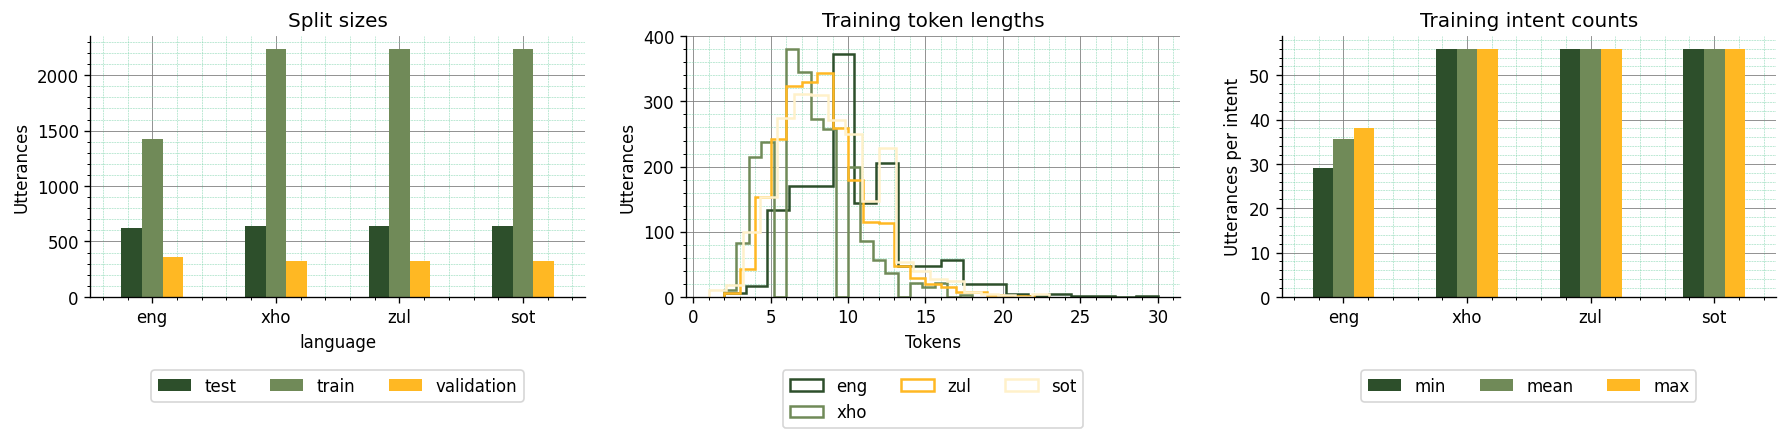

In [62]:
fig,axes = panels(3)
counts.pivot(index='language',columns='split',values='rows').reindex(LANGUAGES).plot.bar(ax=axes[0],rot=0)
axes[0].set(title='Split sizes',ylabel='Utterances')
for j,lang in enumerate(LANGUAGES):
    lengths = data[lang]['train'].clean.map(lambda s:len(tokenize(s)))
    axes[1].hist(lengths,bins=20,histtype='step',label=lang,color=NATURE[j],linewidth=1.5)
axes[1].set(title='Training token lengths',xlabel='Tokens',ylabel='Utterances')
balance = pd.DataFrame({lang:data[lang]['train'].intent.value_counts().describe()[['min','mean','max']]
                        for lang in LANGUAGES}).T
balance.plot.bar(ax=axes[2],rot=0)
axes[2].set(title='Training intent counts',ylabel='Utterances per intent')
finish(fig,'data_overview')


#### Vocabulary and batching
In the following cells we are going to build a separate vocabulary for each language from its training text. Each language’s CNN and LSTM share that vocabulary, label mapping and sequence limit. Index 0 represents padding and index 1 represents unknown words. The length limit follows the training 95th percentile, capped at 128 tokens. Class weights balance the training classes using their training counts only.


In the following cell we are going to build vocabularies, label mappings, sequence limits and class weights.


In [63]:
artifacts, coverage = {}, []
for lang, tables in data.items():
    train = tables['train']
    freq = Counter(token for text in train.clean for token in tokenize(text))
    words = [w for w,n in sorted(freq.items(), key=lambda p: (-p[1],p[0])) if n >= CFG['min_freq']]
    vocab = {'<PAD>': 0, '<UNK>': 1}
    vocab.update({w:i+2 for i,w in enumerate(words[:CFG['max_vocab']-2])})
    labels = sorted(train.intent.unique()); label_to_id = {name:i for i,name in enumerate(labels)}
    lengths = train.clean.map(lambda s: len(tokenize(s)))
    max_len = max(max(CFG['kernels']), min(CFG['max_length_cap'], int(np.ceil(np.quantile(lengths, .95)))))
    nums = train.intent.value_counts().reindex(labels).to_numpy()
    weights = torch.tensor(len(train) / (len(labels)*nums), dtype=torch.float32)
    artifacts[lang] = dict(vocab=vocab, labels=labels, label_to_id=label_to_id, max_len=max_len, weights=weights)
    for split, df in tables.items():
        seqs = [tokenize(s) for s in df.clean]
        coverage.append(dict(language=lang, split=split, vocab=len(vocab), max_len=max_len,
            unk_rate=sum(w not in vocab for seq in seqs for w in seq)/sum(map(len,seqs)),
            truncation_rate=np.mean([len(seq)>max_len for seq in seqs])))
    (OUT / f'{lang}_preprocessing.json').write_text(json.dumps(
        dict(vocab=vocab, labels=labels, max_len=max_len, config=CFG), ensure_ascii=False, indent=2), encoding='utf-8')


In the following cell we are going to report unknown-token and truncation rates.

In [64]:
display(pd.DataFrame(coverage).round(4))
pd.DataFrame(coverage).to_csv(OUT / 'coverage.csv', index=False)

,language,split,vocab,max_len,unk_rate,truncation_rate
0,eng,train,2365,17,0.0000,0.0372
1,eng,test,2365,17,0.0189,0.0418
2,eng,validation,2365,17,0.1055,0.0309
3,xho,train,3805,12,0.0000,0.0438
4,xho,validation,3805,12,0.1238,0.0500
5,xho,test,3805,12,0.1372,0.0500
6,zul,train,5635,13,0.0000,0.0375
7,zul,validation,5635,13,0.2230,0.0469
8,zul,test,5635,13,0.2227,0.0406
9,sot,train,2476,14,0.0000,0.0496


In the following cell we are going to convert tokens and intent labels to tensors.

In [65]:
class IntentDataset(Dataset):
    def __init__(self, df, art):
        self.items = [(torch.tensor([art['vocab'].get(w,1) for w in tokenize(s)[:art['max_len']]], dtype=torch.long),
                       art['label_to_id'][y]) for s,y in zip(df.clean, df.intent)]
    def __len__(self): return len(self.items)
    def __getitem__(self, index): return self.items[index]


In the following cell we are going to pad sequences while retaining their true lengths.

In [66]:
def collate(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)
    x = pad_sequence(sequences, batch_first=True, padding_value=0)
    if x.shape[1] < max(CFG['kernels']):
        x = nn.functional.pad(x, (0,max(CFG['kernels'])-x.shape[1]))
    return x, lengths, torch.tensor(labels, dtype=torch.long)


In the following cell we are going to define reproducible loaders with zero worker processes for notebook compatibility.

In [76]:
def make_loaders(lang):
    gen = torch.Generator().manual_seed(SEED)
    return {split: DataLoader(IntentDataset(df, artifacts[lang]), batch_size=CFG['batch_size'],
                shuffle=(split=='train'), generator=gen if split=='train' else None,
                collate_fn=collate, num_workers=0)
            for split,df in data[lang].items()}


### CNN and LSTM models
In the following cells we are going to define two independent classifiers. The CNN learns local patterns with kernels of width 3, 4 and 5 and combines their pooled features. Its pooling excludes artificial padding windows. The unidirectional LSTM processes the sequence in order and classifies the final real-token hidden state. Both models learn embeddings from scratch and use dropout followed by a linear classification layer.


In [67]:
class CNN(nn.Module):
    def __init__(self, vocab_size, n_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG['embedding_dim'], padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(CFG['embedding_dim'], CFG['filters'], k) for k in CFG['kernels']])
        self.dropout = nn.Dropout(CFG['dropout'])
        self.fc = nn.Linear(CFG['filters']*len(CFG['kernels']), n_classes)
    def forward(self, x, lengths):
        emb = self.embedding(x).transpose(1,2)
        pooled = []
        for conv,k in zip(self.convs, CFG['kernels']):
            features = torch.relu(conv(emb))
            valid = (lengths.to(x.device)-k+1).clamp(min=1)
            positions = torch.arange(features.shape[2], device=x.device)
            mask = positions[None,:] >= valid[:,None]
            pooled.append(features.masked_fill(mask[:,None,:], float('-inf')).amax(dim=2))
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


In [68]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, n_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG['embedding_dim'], padding_idx=0)
        self.lstm = nn.LSTM(CFG['embedding_dim'], CFG['hidden_dim'], batch_first=True)
        self.dropout = nn.Dropout(CFG['dropout'])
        self.fc = nn.Linear(CFG['hidden_dim'], n_classes)
    def forward(self, x, lengths):
        packed = pack_padded_sequence(self.embedding(x), lengths.cpu(), batch_first=True, enforce_sorted=False)
        _,(hidden,_) = self.lstm(packed)
        return self.fc(self.dropout(hidden[-1]))


In the following cell we are going to create a new model with the relevant language vocabulary.

In [70]:
MODEL_CLASSES = {'CNN': CNN, 'LSTM': LSTM}
def new_model(lang, name):
    art = artifacts[lang]
    return MODEL_CLASSES[name](len(art['vocab']),len(art['labels'])).to(DEVICE)


### Models training
In the following cells we are going to train the CNN and LSTM separately for every language. AdamW optimizes weighted cross entropy using raw logits. Validation macro F1 selects the checkpoint, with validation loss breaking exact ties. Early stopping ends training after five epochs without improvement. The test set does not select hyperparameters or checkpoints. Each experiment resets the random seed and creates a newly initialized model.


In the following cell we are going to calculate accuracy and macro precision, recall and F1.

In [71]:
def metric_values(y, pred, n_classes):
    p,r,f,_ = precision_recall_fscore_support(y,pred,labels=list(range(n_classes)),average='macro',zero_division=0)
    return dict(accuracy=accuracy_score(y,pred), precision_macro=p, recall_macro=r, f1_macro=f)


In the following cell we are going to accumulate weighted loss and predictions during training or evaluation.

In [72]:
def run_epoch(model, loader, weights, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, denominator, ys, preds = 0.,0.,[],[]
    with torch.set_grad_enabled(training):
        for x,lengths,y in loader:
            x,y = x.to(DEVICE),y.to(DEVICE)
            logits = model(x,lengths)
            loss_sum = nn.functional.cross_entropy(logits,y,weight=weights,reduction='sum')
            denom = weights[y].sum() if weights is not None else y.new_tensor(y.numel())
            loss = loss_sum/denom
            if training:
                optimizer.zero_grad(set_to_none=True); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
            total_loss += loss_sum.item(); denominator += denom.item()
            ys.extend(y.detach().cpu().tolist()); preds.extend(logits.argmax(1).detach().cpu().tolist())
    return dict(loss=total_loss/denominator, **metric_values(ys,preds,model.fc.out_features)),ys,preds


In the following cell we are going to define checkpoint saving and early stopping.

In [73]:
def train_one(lang,name):
    seed_everything()  # reset initialization and batch order for each architecture
    model = new_model(lang,name)
    loaders = make_loaders(lang)
    weights = artifacts[lang]['weights'].to(DEVICE) if CFG['use_class_weights'] else None
    optimizer = torch.optim.AdamW(model.parameters(),lr=CFG['lr'],weight_decay=CFG['weight_decay'])
    best_score, best_loss, stale = -1.,float('inf'),0
    history=[]; checkpoint=OUT / f'{lang}_{name}.pt'
    for epoch in range(1,CFG['epochs']+1):
        train,_,_ = run_epoch(model,loaders['train'],weights,optimizer)
        val,_,_ = run_epoch(model,loaders['validation'],weights)
        history.append(dict(epoch=epoch, **{'train_'+k:v for k,v in train.items()}, **{'val_'+k:v for k,v in val.items()}))
        improved = val['f1_macro']>best_score or (val['f1_macro']==best_score and val['loss']<best_loss)
        if improved:
            best_score,best_loss,stale=val['f1_macro'],val['loss'],0
            torch.save(model.state_dict(),checkpoint)
        else: stale+=1
        print(f"{lang}/{name} epoch {epoch:02d} train loss={train['loss']:.4f} val F1={val['f1_macro']:.4f}")
        if stale>=CFG['patience']: break
    history=pd.DataFrame(history); history.to_csv(OUT / f'{lang}_{name}_history.csv',index=False)
    return history


### Collecting training histories
In the following cell we are going to initialize the collection of training histories.


In [77]:
histories = {}

In [78]:
histories[('eng', 'CNN')] = train_one('eng', 'CNN')


eng/CNN epoch 01 train loss=3.4790 val F1=0.3307
eng/CNN epoch 02 train loss=2.3257 val F1=0.5007
eng/CNN epoch 03 train loss=1.5445 val F1=0.5829
eng/CNN epoch 04 train loss=1.0053 val F1=0.5850
eng/CNN epoch 05 train loss=0.6337 val F1=0.6582
eng/CNN epoch 06 train loss=0.3950 val F1=0.6730
eng/CNN epoch 07 train loss=0.2339 val F1=0.6773
eng/CNN epoch 08 train loss=0.1466 val F1=0.6924
eng/CNN epoch 09 train loss=0.0978 val F1=0.6853
eng/CNN epoch 10 train loss=0.0614 val F1=0.6633
eng/CNN epoch 11 train loss=0.0502 val F1=0.6848
eng/CNN epoch 12 train loss=0.0373 val F1=0.6845
eng/CNN epoch 13 train loss=0.0295 val F1=0.6929
eng/CNN epoch 14 train loss=0.0256 val F1=0.6907
eng/CNN epoch 15 train loss=0.0177 val F1=0.7090
eng/CNN epoch 16 train loss=0.0162 val F1=0.7053
eng/CNN epoch 17 train loss=0.0126 val F1=0.6931
eng/CNN epoch 18 train loss=0.0108 val F1=0.6927
eng/CNN epoch 19 train loss=0.0079 val F1=0.6979
eng/CNN epoch 20 train loss=0.0082 val F1=0.7027


In [79]:
histories[('eng', 'LSTM')] = train_one('eng', 'LSTM')

eng/LSTM epoch 01 train loss=3.6539 val F1=0.1157
eng/LSTM epoch 02 train loss=3.4841 val F1=0.1876
eng/LSTM epoch 03 train loss=3.2014 val F1=0.2338
eng/LSTM epoch 04 train loss=2.6837 val F1=0.3473
eng/LSTM epoch 05 train loss=2.0679 val F1=0.4467
eng/LSTM epoch 06 train loss=1.5698 val F1=0.5265
eng/LSTM epoch 07 train loss=1.1941 val F1=0.5662
eng/LSTM epoch 08 train loss=0.8967 val F1=0.6221
eng/LSTM epoch 09 train loss=0.6843 val F1=0.6524
eng/LSTM epoch 10 train loss=0.5249 val F1=0.6362
eng/LSTM epoch 11 train loss=0.3929 val F1=0.6661
eng/LSTM epoch 12 train loss=0.3101 val F1=0.6741
eng/LSTM epoch 13 train loss=0.2218 val F1=0.6648
eng/LSTM epoch 14 train loss=0.1664 val F1=0.6729
eng/LSTM epoch 15 train loss=0.1329 val F1=0.6502
eng/LSTM epoch 16 train loss=0.1057 val F1=0.6714
eng/LSTM epoch 17 train loss=0.0837 val F1=0.6449


In [80]:
histories[('xho', 'CNN')] = train_one('xho', 'CNN')

xho/CNN epoch 01 train loss=2.7502 val F1=0.7392
xho/CNN epoch 02 train loss=1.1104 val F1=0.8453
xho/CNN epoch 03 train loss=0.4622 val F1=0.8883
xho/CNN epoch 04 train loss=0.1790 val F1=0.8841
xho/CNN epoch 05 train loss=0.0635 val F1=0.9028
xho/CNN epoch 06 train loss=0.0315 val F1=0.9048
xho/CNN epoch 07 train loss=0.0194 val F1=0.9118
xho/CNN epoch 08 train loss=0.0146 val F1=0.9008
xho/CNN epoch 09 train loss=0.0100 val F1=0.9014
xho/CNN epoch 10 train loss=0.0083 val F1=0.9047
xho/CNN epoch 11 train loss=0.0067 val F1=0.8989
xho/CNN epoch 12 train loss=0.0058 val F1=0.9108


In [81]:
histories[('xho', 'LSTM')] = train_one('xho', 'LSTM')

xho/LSTM epoch 01 train loss=3.5912 val F1=0.3033
xho/LSTM epoch 02 train loss=3.1508 val F1=0.4217
xho/LSTM epoch 03 train loss=2.1580 val F1=0.6741
xho/LSTM epoch 04 train loss=1.1629 val F1=0.8083
xho/LSTM epoch 05 train loss=0.6489 val F1=0.8544
xho/LSTM epoch 06 train loss=0.3740 val F1=0.8814
xho/LSTM epoch 07 train loss=0.2285 val F1=0.8824
xho/LSTM epoch 08 train loss=0.1451 val F1=0.8878
xho/LSTM epoch 09 train loss=0.0972 val F1=0.8841
xho/LSTM epoch 10 train loss=0.0683 val F1=0.8884
xho/LSTM epoch 11 train loss=0.0507 val F1=0.8894
xho/LSTM epoch 12 train loss=0.0389 val F1=0.8894
xho/LSTM epoch 13 train loss=0.0309 val F1=0.8925
xho/LSTM epoch 14 train loss=0.0251 val F1=0.8952
xho/LSTM epoch 15 train loss=0.0205 val F1=0.8985
xho/LSTM epoch 16 train loss=0.0181 val F1=0.8918
xho/LSTM epoch 17 train loss=0.0157 val F1=0.8918
xho/LSTM epoch 18 train loss=0.0138 val F1=0.8918
xho/LSTM epoch 19 train loss=0.0121 val F1=0.8951
xho/LSTM epoch 20 train loss=0.0102 val F1=0.8918


In [82]:
histories[('zul', 'CNN')] = train_one('zul', 'CNN')

zul/CNN epoch 01 train loss=3.2281 val F1=0.4730
zul/CNN epoch 02 train loss=1.8368 val F1=0.5642
zul/CNN epoch 03 train loss=1.0711 val F1=0.6384
zul/CNN epoch 04 train loss=0.5976 val F1=0.6762
zul/CNN epoch 05 train loss=0.3031 val F1=0.6894
zul/CNN epoch 06 train loss=0.1547 val F1=0.6988
zul/CNN epoch 07 train loss=0.0781 val F1=0.7120
zul/CNN epoch 08 train loss=0.0458 val F1=0.7103
zul/CNN epoch 09 train loss=0.0300 val F1=0.7046
zul/CNN epoch 10 train loss=0.0209 val F1=0.7076
zul/CNN epoch 11 train loss=0.0174 val F1=0.7145
zul/CNN epoch 12 train loss=0.0136 val F1=0.7104
zul/CNN epoch 13 train loss=0.0116 val F1=0.7022
zul/CNN epoch 14 train loss=0.0096 val F1=0.7050
zul/CNN epoch 15 train loss=0.0090 val F1=0.7109
zul/CNN epoch 16 train loss=0.0066 val F1=0.7018


In [83]:
histories[('zul', 'LSTM')] = train_one('zul', 'LSTM')

zul/LSTM epoch 01 train loss=3.6302 val F1=0.1779
zul/LSTM epoch 02 train loss=3.3720 val F1=0.2545
zul/LSTM epoch 03 train loss=2.7405 val F1=0.3521
zul/LSTM epoch 04 train loss=1.8943 val F1=0.4366
zul/LSTM epoch 05 train loss=1.3233 val F1=0.5394
zul/LSTM epoch 06 train loss=0.9580 val F1=0.5923
zul/LSTM epoch 07 train loss=0.6998 val F1=0.6041
zul/LSTM epoch 08 train loss=0.5201 val F1=0.6211
zul/LSTM epoch 09 train loss=0.3709 val F1=0.6370
zul/LSTM epoch 10 train loss=0.2686 val F1=0.6388
zul/LSTM epoch 11 train loss=0.1915 val F1=0.6297
zul/LSTM epoch 12 train loss=0.1379 val F1=0.6532
zul/LSTM epoch 13 train loss=0.1053 val F1=0.6442
zul/LSTM epoch 14 train loss=0.0852 val F1=0.6471
zul/LSTM epoch 15 train loss=0.0703 val F1=0.6306
zul/LSTM epoch 16 train loss=0.0553 val F1=0.6468
zul/LSTM epoch 17 train loss=0.0432 val F1=0.6646
zul/LSTM epoch 18 train loss=0.0363 val F1=0.6364
zul/LSTM epoch 19 train loss=0.0344 val F1=0.6314
zul/LSTM epoch 20 train loss=0.0275 val F1=0.6382


In [84]:
histories[('sot', 'CNN')] = train_one('sot', 'CNN')

sot/CNN epoch 01 train loss=3.0856 val F1=0.5346
sot/CNN epoch 02 train loss=1.7224 val F1=0.6403
sot/CNN epoch 03 train loss=1.0353 val F1=0.7098
sot/CNN epoch 04 train loss=0.6264 val F1=0.7593
sot/CNN epoch 05 train loss=0.3912 val F1=0.7278
sot/CNN epoch 06 train loss=0.2269 val F1=0.7573
sot/CNN epoch 07 train loss=0.1521 val F1=0.7717
sot/CNN epoch 08 train loss=0.0962 val F1=0.7648
sot/CNN epoch 09 train loss=0.0686 val F1=0.7574
sot/CNN epoch 10 train loss=0.0504 val F1=0.7960
sot/CNN epoch 11 train loss=0.0433 val F1=0.7896
sot/CNN epoch 12 train loss=0.0316 val F1=0.7831
sot/CNN epoch 13 train loss=0.0237 val F1=0.7931
sot/CNN epoch 14 train loss=0.0188 val F1=0.7888
sot/CNN epoch 15 train loss=0.0185 val F1=0.7824


In [85]:
histories[('sot', 'LSTM')] = train_one('sot', 'LSTM')

sot/LSTM epoch 01 train loss=3.6219 val F1=0.2195
sot/LSTM epoch 02 train loss=3.2693 val F1=0.3053
sot/LSTM epoch 03 train loss=2.4319 val F1=0.5137
sot/LSTM epoch 04 train loss=1.6615 val F1=0.6099
sot/LSTM epoch 05 train loss=1.1791 val F1=0.6850
sot/LSTM epoch 06 train loss=0.8636 val F1=0.6930
sot/LSTM epoch 07 train loss=0.6362 val F1=0.7154
sot/LSTM epoch 08 train loss=0.4866 val F1=0.7439
sot/LSTM epoch 09 train loss=0.3504 val F1=0.7420
sot/LSTM epoch 10 train loss=0.2707 val F1=0.7419
sot/LSTM epoch 11 train loss=0.2065 val F1=0.7698
sot/LSTM epoch 12 train loss=0.1610 val F1=0.7536
sot/LSTM epoch 13 train loss=0.1299 val F1=0.7592
sot/LSTM epoch 14 train loss=0.0974 val F1=0.7571
sot/LSTM epoch 15 train loss=0.0827 val F1=0.7771
sot/LSTM epoch 16 train loss=0.0674 val F1=0.7739
sot/LSTM epoch 17 train loss=0.0574 val F1=0.7689
sot/LSTM epoch 18 train loss=0.0471 val F1=0.7709
sot/LSTM epoch 19 train loss=0.0421 val F1=0.7603
sot/LSTM epoch 20 train loss=0.0341 val F1=0.7705


In the following cell we are going to confirm that all eight training histories are available.

In [86]:
assert len(histories) == 8

### Plotting training curves
In the following cell we are going to define a compact learning-curve figure. Each row represents an architecture and the three columns show loss, accuracy and macro F1. Training curves include dropout during updates; validation curves use evaluation mode.

In [88]:
def plot_learning(lang):
    fig,axes = panels(6)
    for row,name in enumerate(MODEL_NAMES):
        h = histories[(lang,name)]
        for col,metric in enumerate(['loss','accuracy','f1_macro']):
            ax = axes[row*3+col]
            ax.plot(h.epoch,h['train_'+metric],label='Training',color=MODEL_COLORS[name])
            ax.plot(h.epoch,h['val_'+metric],label='Validation',color=NATURE[6],linestyle='--')
            ax.set(title=f'{name}: {metric}',xlabel='Epoch',ylabel=metric)
    fig.suptitle(LANGUAGES[lang])
    finish(fig,f'{lang}_learning_curves')

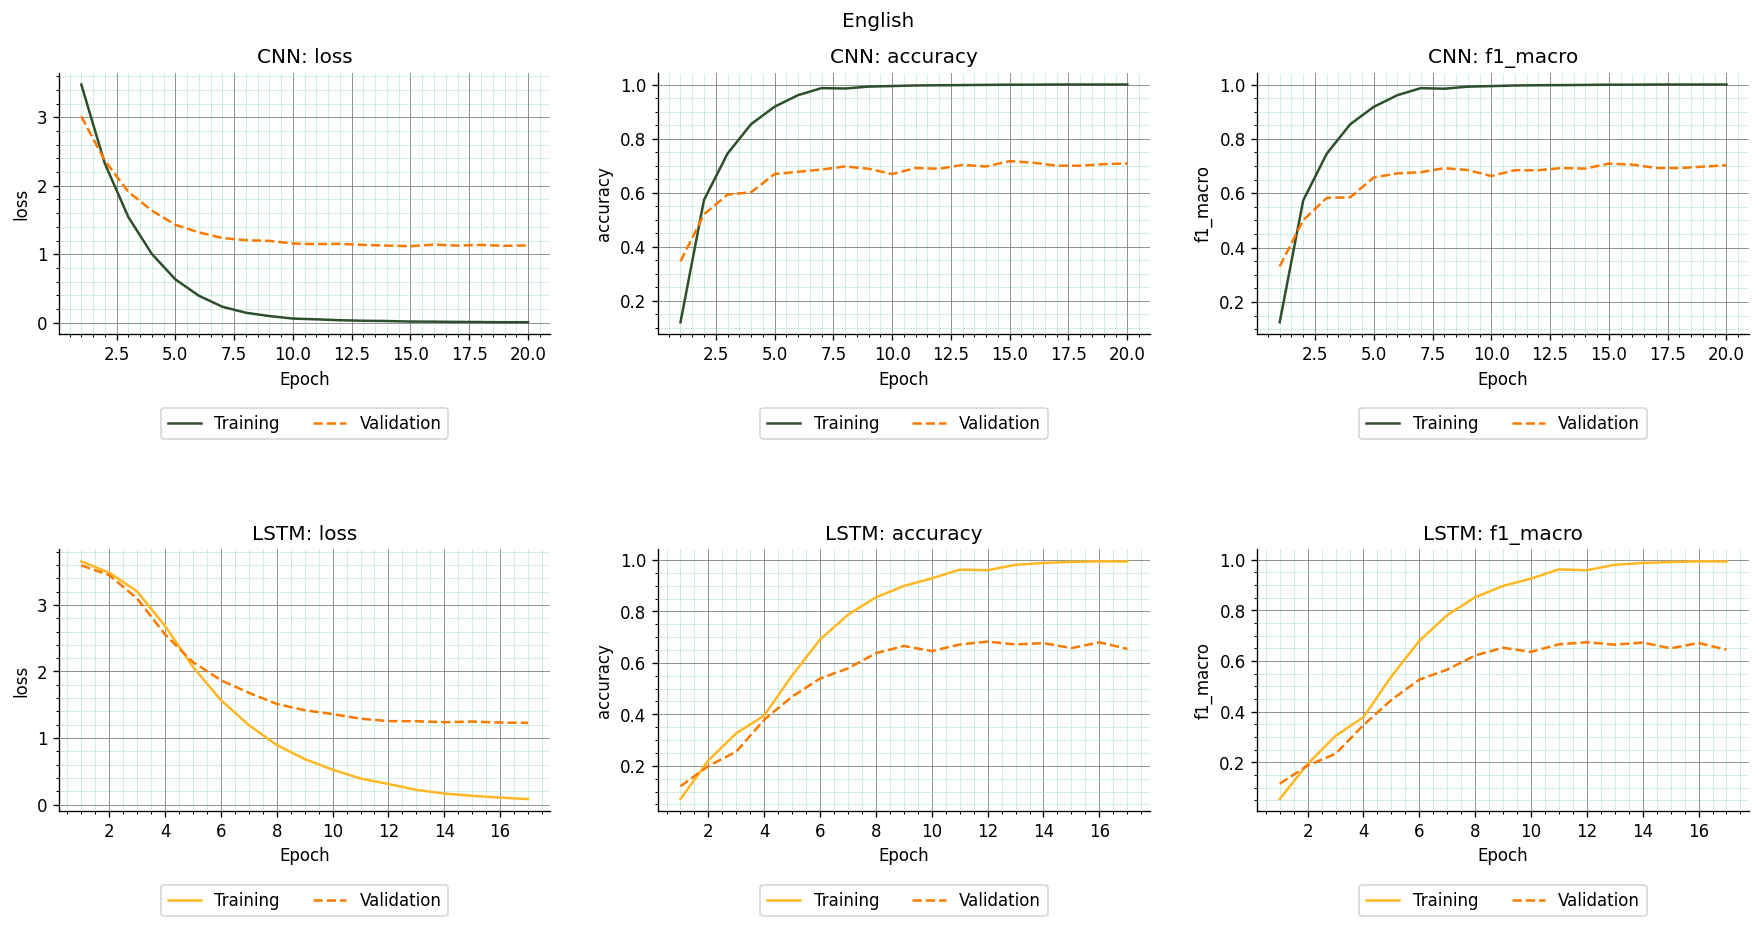

In [89]:
plot_learning('eng')

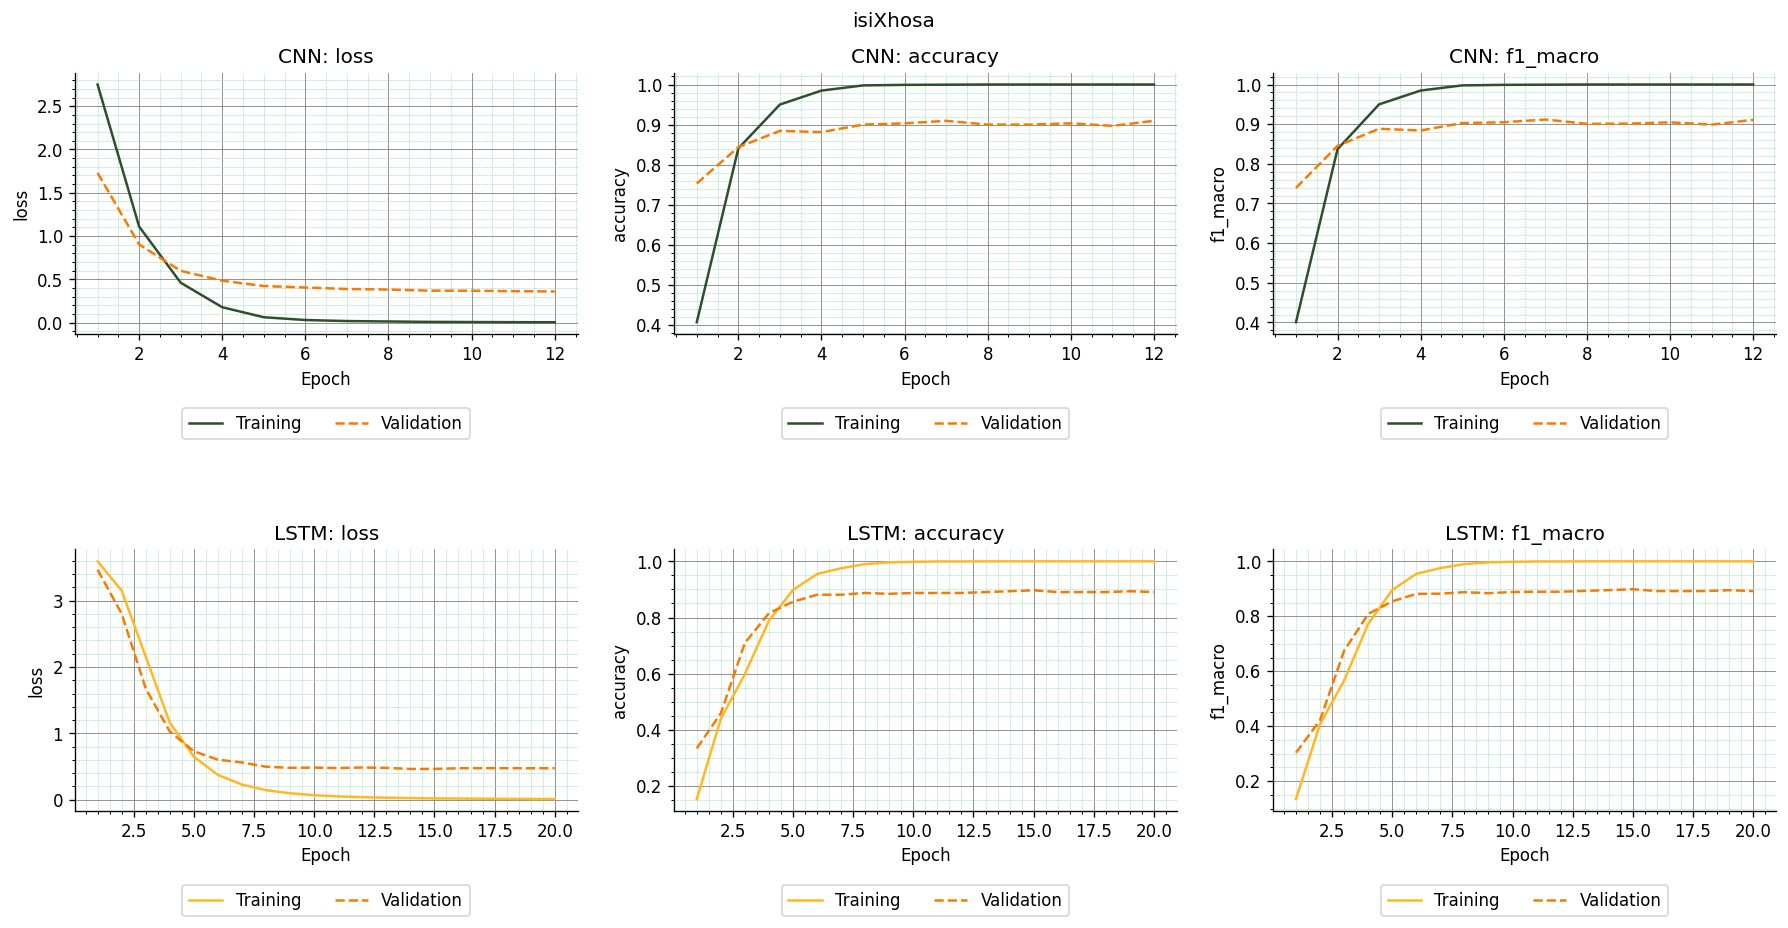

In [90]:
plot_learning('xho')

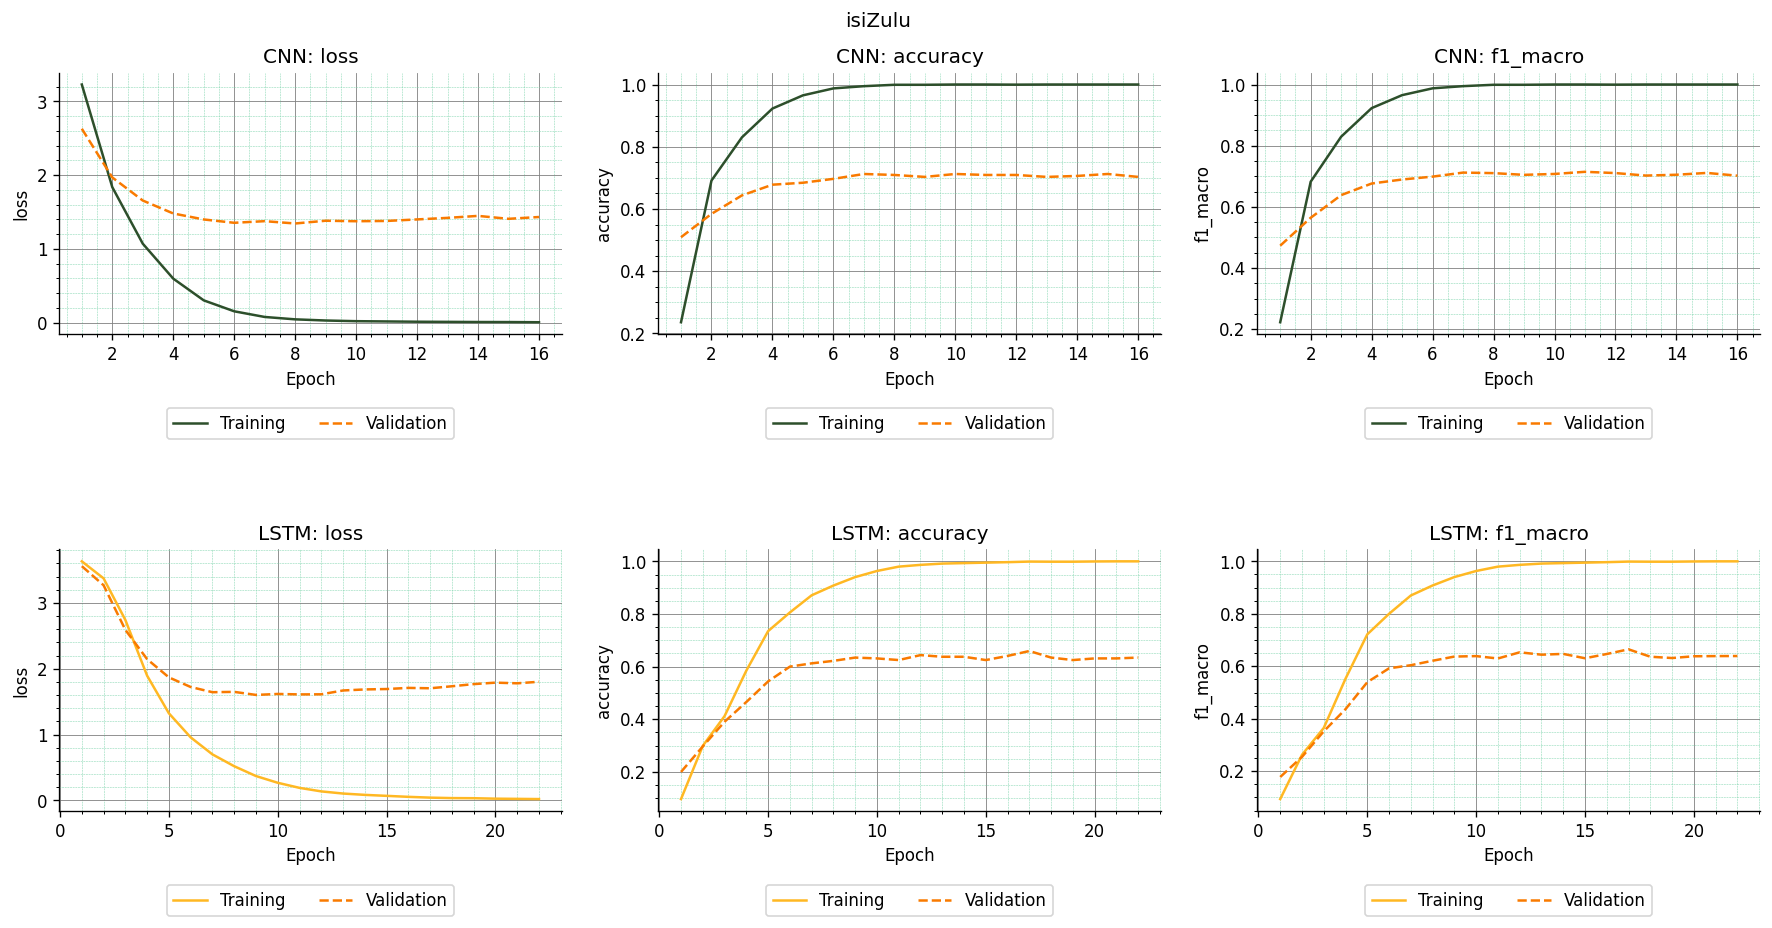

In [91]:
plot_learning('zul')

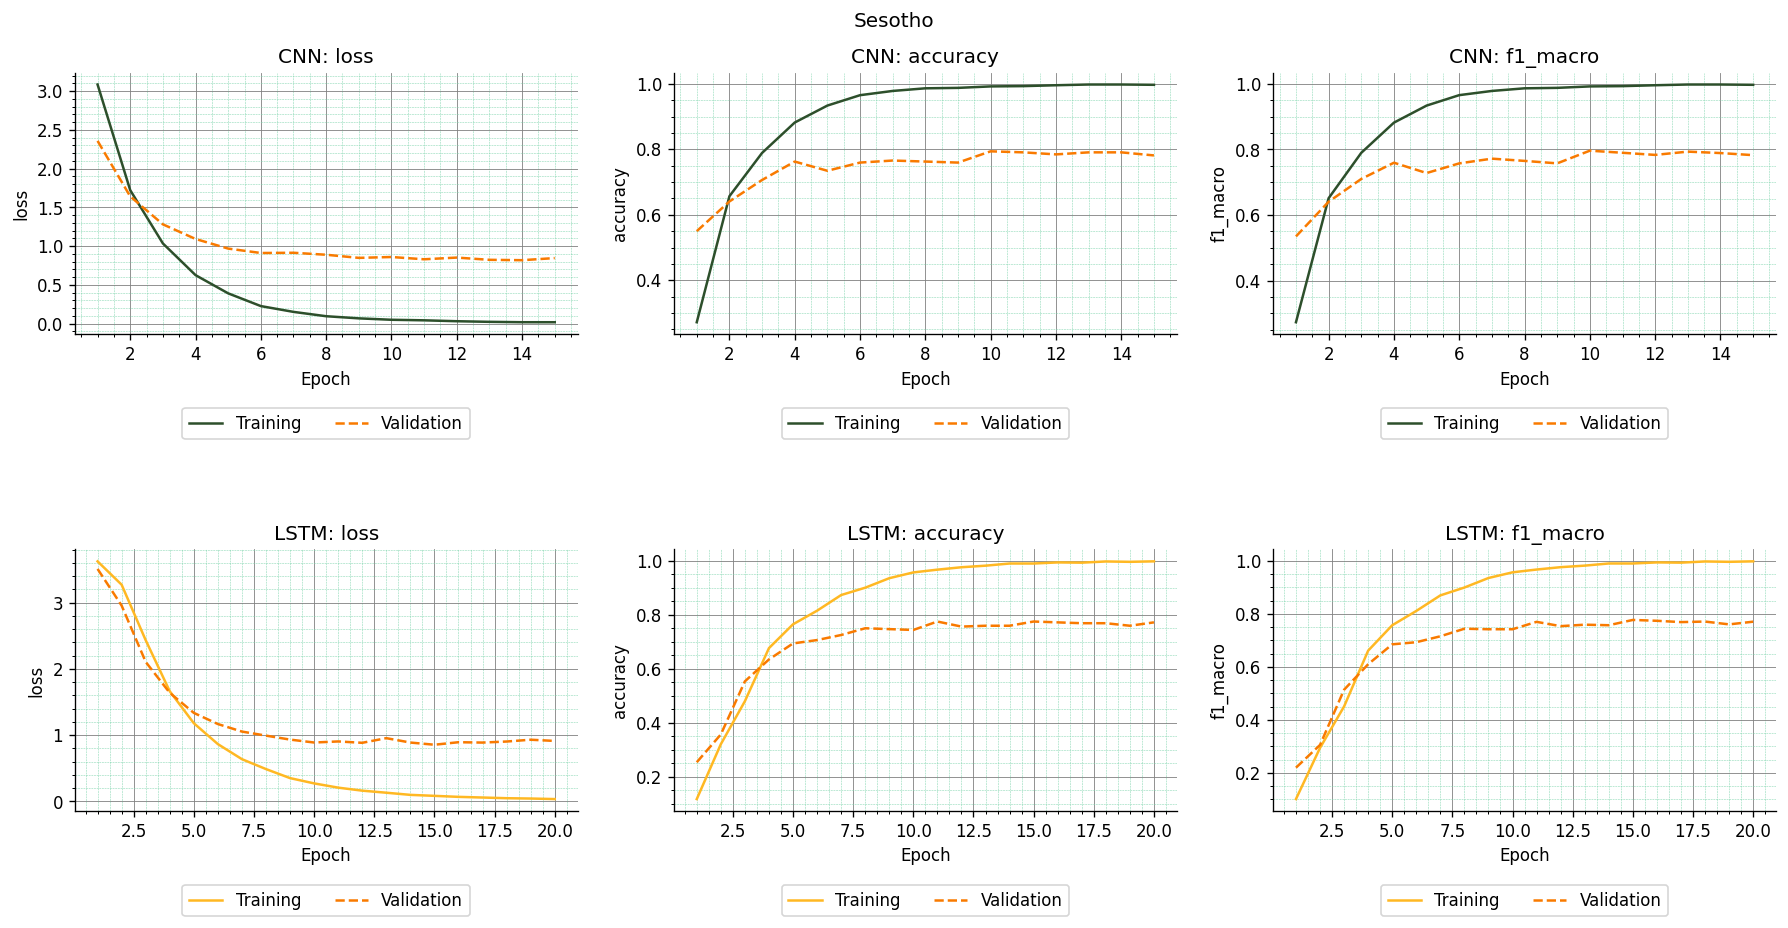

In [92]:
plot_learning('sot')

#### Preparing explanation analysis
In the following cells we are going to reload the best checkpoints created above and analyse their predictions.

In [93]:
OUT = ROOT / 'analysis'; OUT.mkdir(parents=True,exist_ok=True)
manifest = {'settings':dict(per_intent=PER_INTENT,budgets=BUDGETS,random_repeats=RANDOM_REPEATS,
             bootstraps=BOOTSTRAPS,seed=SEED), 'config':CFG, 'torch':str(torch.__version__),
             'python':sys.version, 'device':str(DEVICE), 'inputs':{}}
for path in sorted(MODEL_DIR.glob('*')):
    if path.is_file(): manifest['inputs'][path.name] = hashlib.sha256(path.read_bytes()).hexdigest()
(OUT / 'manifest.json').write_text(json.dumps(manifest,indent=2))


4589

### Loading the newly trained models
In the following cell we are going to define checkpoint loading and encoding using the vocabularies created in this notebook.

In [95]:
def load_model(lang, name, root=MODEL_DIR):
    art = artifacts[lang]
    cls = CNN if name == 'CNN' else LSTM
    model = cls(len(art['vocab']), len(art['labels'])).to(DEVICE)
    model.load_state_dict(torch.load(root / f'{lang}_{name}.pt',map_location=DEVICE,weights_only=True))
    return model.eval()

def encode(lang, text):
    art = artifacts[lang]
    tokens = tokenize(text)[:art['max_len']]
    ids = [art['vocab'].get(w,1) for w in tokens]
    return tokens, ids

### Predicting perturbed sequences
In the following cell we are going to calculate probabilities in batches while retaining the correct sequence lengths.


In [96]:
@torch.inference_mode()
def probabilities(model, sequences):
    outputs = []
    for start in range(0,len(sequences),INFERENCE_BATCH):
        batch = sequences[start:start+INFERENCE_BATCH]
        if any(len(s)==0 for s in batch): raise ValueError('Empty perturbation is not supported.')
        tensors = [torch.tensor(s,dtype=torch.long) for s in batch]
        lengths = torch.tensor([len(s) for s in batch],dtype=torch.long)
        x = pad_sequence(tensors,batch_first=True,padding_value=0)
        if x.shape[1] < max(CFG['kernels']):
            x = nn.functional.pad(x,(0,max(CFG['kernels'])-x.shape[1]))
        outputs.append(model(x.to(DEVICE),lengths).softmax(1).cpu().numpy())
    return np.concatenate(outputs)

### Selecting the explanation sample
In the following cell we are going to select the same examples for both architectures without inspecting predictions. Normalized-text duplicates and utterances with fewer than two retained tokens are excluded from this analysis. Up to five examples are sampled per intent by default. The audit records exclusions, sampled intent counts and truncation. This explanation sample is distinct from the full held-out benchmark.


In [97]:
samples, sampling_audit = {}, []
for lang in LANGUAGES:
    df = pd.read_csv(MODEL_DIR / f'{lang}_test_split.csv',keep_default_na=False)
    df['example_id'] = np.arange(len(df))
    df['clean'] = df.text.map(clean_text)
    df['full_length'] = df.text.map(lambda t:len(tokenize(t)))
    df['length'] = df.text.map(lambda t:len(encode(lang,t)[1]))
    unique = df.drop_duplicates('clean')
    eligible = unique[unique.length>=2].copy()
    groups = [g if PER_INTENT is None else g.sample(min(PER_INTENT,len(g)),random_state=SEED)
              for _,g in eligible.groupby('intent',sort=True)]
    if not groups: raise ValueError(f'No eligible examples for {lang}')
    sample = pd.concat(groups).sort_values('example_id').reset_index(drop=True)
    samples[lang] = sample
    sample.to_csv(OUT / f'{lang}_explanation_sample.csv',index=False)
    sampling_audit.append(dict(language=lang,original=len(df),duplicate_texts=len(df)-len(unique),
        short_excluded=len(unique)-len(eligible),eligible=len(eligible),sampled=len(sample),
        sampled_intents=sample.intent.nunique(),truncated=int((sample.full_length>sample.length).sum())))
display(pd.DataFrame(sampling_audit))
pd.DataFrame(sampling_audit).to_csv(OUT / 'sampling_audit.csv',index=False)


,language,original,duplicate_texts,short_excluded,eligible,sampled,sampled_intents,truncated
0,eng,622,0,0,622,200,40,1
1,xho,640,0,0,640,200,40,7
2,zul,640,0,0,640,200,40,12
3,sot,640,0,0,640,200,40,6


### Measuring word importance
In the following cells we are going to replace or delete one token at a time and observe the probability change for the original predicted class. That target class stays fixed even when a perturbed input changes the prediction.

$$
I_i=p(c^*\mid x)-p(c^*\mid x^{(i)})
$$
Here $x$ is the original retained token sequence, $c^*$ is its predicted class and $x^{(i)}$ is the sequence after replacing token position $i$ with `<UNK>` or deleting it. Positive scores indicate support for the original prediction under that operation. Negative scores indicate that perturbation increases its probability. Repeated words are assessed by position. Replacing an existing unknown token has no effect.

Tokens are ranked by signed importance from highest to lowest. Ties are resolved by position and tie rates are reported. Each budget affects a rounded-up proportion of tokens, with at least one token affected and at least one retained. Consequently, short sequences may have identical effective budgets; the actual fractions are saved.

In the following cell we are going to define unknown-token replacement, deletion, ranking and reproducible random orders.


In [98]:
def perturb(ids, selected, operator):
    selected = set(int(i) for i in selected)
    if operator == 'unk': return [1 if i in selected else value for i,value in enumerate(ids)]
    if operator == 'delete': return [value for i,value in enumerate(ids) if i not in selected]
    raise ValueError(operator)

def importance(model, ids, target, base, operator):
    variants = [perturb(ids,[i],operator) for i in range(len(ids))]
    return base - probabilities(model,variants)[:,target]

def ranked(scores):
    return np.argsort(-np.asarray(scores),kind='stable')

def stable_rng(lang, example_id):
    digest = hashlib.sha256(f'{SEED}:{lang}:{example_id}'.encode()).digest()
    return np.random.default_rng(int.from_bytes(digest[:8],'little'))


### Comparing ranked and random token sets
In the following cells we are going to evaluate both importance rankings under both perturbation operations. Cross-operator comparisons reveal whether a ranking's apparent advantage depends on the same operation used to construct it. Each example also receives twenty random orders shared across architectures.

The probability drop measures how much the selected tokens affect the original confidence. The retention gap measures how well the selected tokens preserve confidence when all other positions are removed or replaced. Higher drops indicate greater sensitivity; smaller retention gaps indicate stronger preservation. Deletion-based versions follow ERASER-style comprehensiveness and sufficiency, while replacement versions are explicitly treated as analogues. Negative values remain visible. Prediction flips measure sensitivity and are not automatically accuracy losses. Rankings remain fixed throughout each example’s budget evaluation.


In the following cell we are going to evaluate probability drops, retention gaps and flips at each token budget.

In [99]:
def evaluate_order(model, ids, target, base, order, operator):
    variants, counts = [], []
    for fraction in BUDGETS:
        k = min(len(ids)-1,max(1,int(np.ceil(fraction*len(ids)))))
        selected = set(order[:k]); complement = set(range(len(ids))) - selected
        counts.append(k)
        variants += [perturb(ids,selected,operator),perturb(ids,complement,operator)]
    prob = probabilities(model,variants)
    rows = []
    for j,(fraction,k) in enumerate(zip(BUDGETS,counts)):
        removed,retained = prob[2*j],prob[2*j+1]
        rows.append(dict(budget=fraction,k=k,actual_fraction=k/len(ids),
             drop=float(base-removed[target]),retention_gap=float(base-retained[target]),
             flip=float(removed.argmax()!=target)))
    return rows


In the following cell we are going to save the original prediction and both per-token importance scores.

In [100]:
def analyse_example(model, lang, name, row):
    tokens,ids = encode(lang,row.text)
    original = probabilities(model,[ids])[0]
    target = int(original.argmax()); base = float(original[target])
    label = artifacts[lang]['labels'][target]
    meta = dict(language=lang,model=name,example_id=int(row.example_id),intent=row.intent,
                predicted_intent=label,correct=bool(label==row.intent),base_probability=base,
                length=len(ids),unk_fraction=float(np.mean(np.array(ids)==1)))
    scores = {op:importance(model,ids,target,base,op) for op in ['unk','delete']}
    token_rows = [dict(**meta,position=i,token=token,token_id=ids[i],
                 unk_score=float(scores['unk'][i]),delete_score=float(scores['delete'][i]))
                 for i,token in enumerate(tokens)]
    return ids,target,base,meta,scores,token_rows


In the following cell we are going to evaluate both rankings and average random repetitions within each example.

In [101]:
def evaluate_example(model,lang,row,ids,target,base,meta,scores):
    rng = stable_rng(lang,int(row.example_id))
    random_orders = [rng.permutation(len(ids)) for _ in range(RANDOM_REPEATS)]
    records = []
    for operator in ['unk','delete']:
        for method in ['unk','delete','random']:
            orders = random_orders if method=='random' else [ranked(scores[method])]
            trials = [evaluate_order(model,ids,target,base,order,operator) for order in orders]
            for j in range(len(BUDGETS)):
                values = trials[0][j].copy()
                for key in ['drop','retention_gap','flip']:
                    values[key] = float(np.mean([trial[j][key] for trial in trials]))
                records.append(dict(**meta,ranking=method,operator=operator,**values))
    return records


### Agreement between explanation methods
In the following cell we are going to compare the UNK and deletion rankings using Spearman correlation and Jaccard overlap of selected positions. Correlation measures score ordering, while Jaccard measures the fraction of selected positions shared by the two methods. Constant score vectors have undefined correlation and are reported separately. Agreement can be affected by ties and does not establish explanation correctness. This analysis concerns perturbation operators, not independently trained seeds.


In [102]:
def agreement(scores, meta):
    a,b = scores['unk'],scores['delete']
    constant = np.ptp(a)==0 or np.ptp(b)==0
    rho = np.nan if constant else float(spearmanr(a,b).statistic)
    tie_rate = max(1-len(np.unique(a))/len(a),1-len(np.unique(b))/len(b))
    rows = []
    for q in BUDGETS:
        k = min(len(a)-1,max(1,int(np.ceil(q*len(a)))))
        sa,sb = set(ranked(a)[:k]),set(ranked(b)[:k])
        rows.append(dict(**meta,budget=q,spearman=rho,constant_scores=constant,
                         tie_rate=tie_rate,jaccard=len(sa&sb)/len(sa|sb)))
    return rows


### Running the explanation experiments
In the following cells we are going to evaluate every sampled utterance for all eight trained models. Each completed experiment saves its per-example measurements, token scores and agreement records. The analysis includes both correctly and incorrectly classified utterances.


In [103]:
def run_experiment(lang,name):
    model = load_model(lang,name)
    evaluations,tokens,agreements = [],[],[]
    for position,row in enumerate(samples[lang].itertuples(index=False)):
        ids,target,base,meta,scores,token_rows = analyse_example(model,lang,name,row)
        evaluations.extend(evaluate_example(model,lang,row,ids,target,base,meta,scores))
        tokens.extend(token_rows); agreements.extend(agreement(scores,meta))
        if (position+1)%25==0: print(lang,name,position+1,'/',len(samples[lang]))
    for suffix,records in [('evaluation',evaluations),('tokens',tokens),('agreement',agreements)]:
        pd.DataFrame(records).to_csv(OUT / f'{lang}_{name}_{suffix}.csv',index=False)
    print('Completed:',lang,name)


In [104]:
run_experiment('eng','CNN')

eng CNN 25 / 200
eng CNN 50 / 200
eng CNN 75 / 200
eng CNN 100 / 200
eng CNN 125 / 200
eng CNN 150 / 200
eng CNN 175 / 200
eng CNN 200 / 200
Completed: eng CNN


In [105]:
run_experiment('eng','LSTM')

eng LSTM 25 / 200
eng LSTM 50 / 200
eng LSTM 75 / 200
eng LSTM 100 / 200
eng LSTM 125 / 200
eng LSTM 150 / 200
eng LSTM 175 / 200
eng LSTM 200 / 200
Completed: eng LSTM


In [106]:
run_experiment('xho','CNN')

xho CNN 25 / 200
xho CNN 50 / 200
xho CNN 75 / 200
xho CNN 100 / 200
xho CNN 125 / 200
xho CNN 150 / 200
xho CNN 175 / 200
xho CNN 200 / 200
Completed: xho CNN


In [107]:
run_experiment('xho','LSTM')

xho LSTM 25 / 200
xho LSTM 50 / 200
xho LSTM 75 / 200
xho LSTM 100 / 200
xho LSTM 125 / 200
xho LSTM 150 / 200
xho LSTM 175 / 200
xho LSTM 200 / 200
Completed: xho LSTM


In [108]:
run_experiment('zul','CNN')

zul CNN 25 / 200
zul CNN 50 / 200
zul CNN 75 / 200
zul CNN 100 / 200
zul CNN 125 / 200
zul CNN 150 / 200
zul CNN 175 / 200
zul CNN 200 / 200
Completed: zul CNN


In [109]:
run_experiment('zul','LSTM')

zul LSTM 25 / 200
zul LSTM 50 / 200
zul LSTM 75 / 200
zul LSTM 100 / 200
zul LSTM 125 / 200
zul LSTM 150 / 200
zul LSTM 175 / 200
zul LSTM 200 / 200
Completed: zul LSTM


In [110]:
run_experiment('sot','CNN')

sot CNN 25 / 200
sot CNN 50 / 200
sot CNN 75 / 200
sot CNN 100 / 200
sot CNN 125 / 200
sot CNN 150 / 200
sot CNN 175 / 200
sot CNN 200 / 200
Completed: sot CNN


In [111]:
run_experiment('sot','LSTM')

sot LSTM 25 / 200
sot LSTM 50 / 200
sot LSTM 75 / 200
sot LSTM 100 / 200
sot LSTM 125 / 200
sot LSTM 150 / 200
sot LSTM 175 / 200
sot LSTM 200 / 200
Completed: sot LSTM


### Combining analysis records
In the following cell we are going to combine the outputs generated by this run and normalize their data types.

In [112]:
def collect(suffix):
    return pd.concat([pd.read_csv(OUT / f'{lang}_{name}_{suffix}.csv',keep_default_na=False)
                      for lang in LANGUAGES for name in MODEL_NAMES],ignore_index=True)
evaluation = collect('evaluation')
token_scores = collect('tokens')
operator_agreement = collect('agreement')
operator_agreement['spearman'] = pd.to_numeric(operator_agreement.spearman,errors='coerce')
for frame in [evaluation,token_scores,operator_agreement]:
    frame['correct'] = frame.correct.map(lambda v:str(v).lower()=='true')
evaluation.to_csv(OUT / 'all_evaluations.csv',index=False)
print('Per-example evaluation records:',len(evaluation))

Per-example evaluation records: 38400


### Summarizing outcomes
In the following cell we are going to average examples within each intent and then average intents equally. This prevents frequent intents from dominating the main summaries. Random repetitions have already been averaged within each example. The support table reports the numbers of correct and incorrect predictions and their unknown-token rates.

In [113]:
GROUPS = ['language','model','ranking','operator','budget']
METRICS = ['drop','retention_gap','flip']
intent_means = evaluation.groupby(GROUPS+['intent'])[METRICS].mean().reset_index()
summary = intent_means.groupby(GROUPS)[METRICS].mean().reset_index()
summary.to_csv(OUT / 'macro_intent_summary.csv',index=False)
display(summary.head(12).round(4))
examples = evaluation.drop_duplicates(['language','model','example_id'])
support = examples.groupby(['language','model','correct']).agg(
    examples=('example_id','size'),intents=('intent','nunique'),
    mean_unk_fraction=('unk_fraction','mean')).reset_index()
display(support)
support.to_csv(OUT / 'correct_error_support.csv',index=False)

,language,model,ranking,operator,budget,drop,retention_gap,flip
0,eng,CNN,delete,delete,0.1,0.4070,0.6929,0.2500
1,eng,CNN,delete,delete,0.2,0.6627,0.5617,0.4900
2,eng,CNN,delete,delete,0.3,0.7642,0.4412,0.6750
3,eng,CNN,delete,delete,0.5,0.8847,0.1932,0.8950
4,eng,CNN,delete,unk,0.1,0.2935,0.5594,0.1450
5,eng,CNN,delete,unk,0.2,0.5817,0.3626,0.3850
6,eng,CNN,delete,unk,0.3,0.7276,0.2456,0.6200
7,eng,CNN,delete,unk,0.5,0.8570,0.0884,0.8300
8,eng,CNN,random,delete,0.1,0.1009,0.8778,0.0507
9,eng,CNN,random,delete,0.2,0.2444,0.8308,0.1292


,language,model,correct,examples,intents,mean_unk_fraction
0,eng,CNN,False,8,8,0.086844
1,eng,CNN,True,192,40,0.008535
2,eng,LSTM,False,8,7,0.093094
3,eng,LSTM,True,192,40,0.008274
4,sot,CNN,False,41,24,0.064711
5,sot,CNN,True,159,39,0.065669
6,sot,LSTM,False,43,25,0.070386
7,sot,LSTM,True,157,40,0.064127
8,xho,CNN,False,24,16,0.389087
9,xho,CNN,True,176,40,0.096335


### Estimating uncertainty
In the following cell we are going to compare each ranked probability drop with the same example’s averaged random baseline. Bootstrap resampling takes place within each intent, preserving the fixed intent set. The resulting 95% intervals describe sampled-example uncertainty conditional on these trained models and random draws. They do not measure training-seed uncertainty or establish significance across many comparisons. Related examples may violate the independence assumption.


In [114]:
def paired_interval(frame):
    pivot = frame.pivot(index=['intent','example_id'],columns='ranking',values='drop')
    rng = np.random.default_rng(SEED)
    records = []
    for method in ['unk','delete']:
        delta = (pivot[method]-pivot['random']).dropna()
        groups = [g.to_numpy() for _,g in delta.groupby(level='intent')]
        draws = np.zeros(BOOTSTRAPS)
        for values in groups:
            draws += rng.choice(values,size=(BOOTSTRAPS,len(values)),replace=True).mean(axis=1)/len(groups)
        records.append(dict(ranking=method,mean_gain=float(np.mean([g.mean() for g in groups])),
                       low=float(np.quantile(draws,.025)),high=float(np.quantile(draws,.975)),
                       n_examples=len(delta),n_intents=len(groups)))
    return records

### Calculating paired intervals
In the following cell we are going to calculate and save the mean ranked-minus-random gains and their descriptive intervals.


In [115]:
interval_rows = []
for keys,frame in evaluation.groupby(['language','model','operator','budget']):
    for record in paired_interval(frame):
        interval_rows.append(dict(zip(['language','model','operator','budget'],keys),**record))
intervals = pd.DataFrame(interval_rows)
intervals.to_csv(OUT / 'paired_drop_intervals.csv',index=False)
display(intervals.head(12).round(4))

,language,model,operator,budget,ranking,mean_gain,low,high,n_examples,n_intents
0,eng,CNN,delete,0.1,unk,0.2915,0.2641,0.3180,200,40
1,eng,CNN,delete,0.1,delete,0.3061,0.2776,0.3305,200,40
2,eng,CNN,delete,0.2,unk,0.4145,0.3922,0.4355,200,40
3,eng,CNN,delete,0.2,delete,0.4184,0.3944,0.4411,200,40
4,eng,CNN,delete,0.3,unk,0.3952,0.3709,0.4166,200,40
5,eng,CNN,delete,0.3,delete,0.3698,0.3440,0.3943,200,40
6,eng,CNN,delete,0.5,unk,0.2515,0.2344,0.2682,200,40
7,eng,CNN,delete,0.5,delete,0.2528,0.2362,0.2711,200,40
8,eng,CNN,unk,0.1,unk,0.2631,0.2372,0.2905,200,40
9,eng,CNN,unk,0.1,delete,0.2260,0.1990,0.2495,200,40


### Visualizing explanation outcomes
In the following figures we are going to compare the two rankings with the random baseline. The three columns show probability drop, retention gap and prediction flip rate. Each figure contains two rows, one for each model. The x-axis shows requested budgets; rounded actual fractions remain available in the saved tables.

In [116]:
def plot_outcomes(lang,operator):
    fig,axes = panels(6)
    for row,name in enumerate(MODEL_NAMES):
        subset = summary[(summary.language==lang)&(summary.model==name)&(summary.operator==operator)]
        for col,metric in enumerate(['drop','retention_gap','flip']):
            ax = axes[row*3+col]
            for method in ['unk','delete','random']:
                line = subset[subset.ranking==method].sort_values('budget')
                ax.plot(line.budget,line[metric],marker='o',label=method,color=RANK_COLORS[method])
            ax.set(title=f'{name}: {metric}',xlabel='Requested token fraction',ylabel=metric)
    fig.suptitle(f'{LANGUAGES[lang]} · evaluation operator: {operator}')
    finish(fig,f'{lang}_{operator}_explanation_outcomes')

### Explanation outcomes for eng: unk
In the following figure we are going to compare both architectures on three related explanation measures under this perturbation operator.


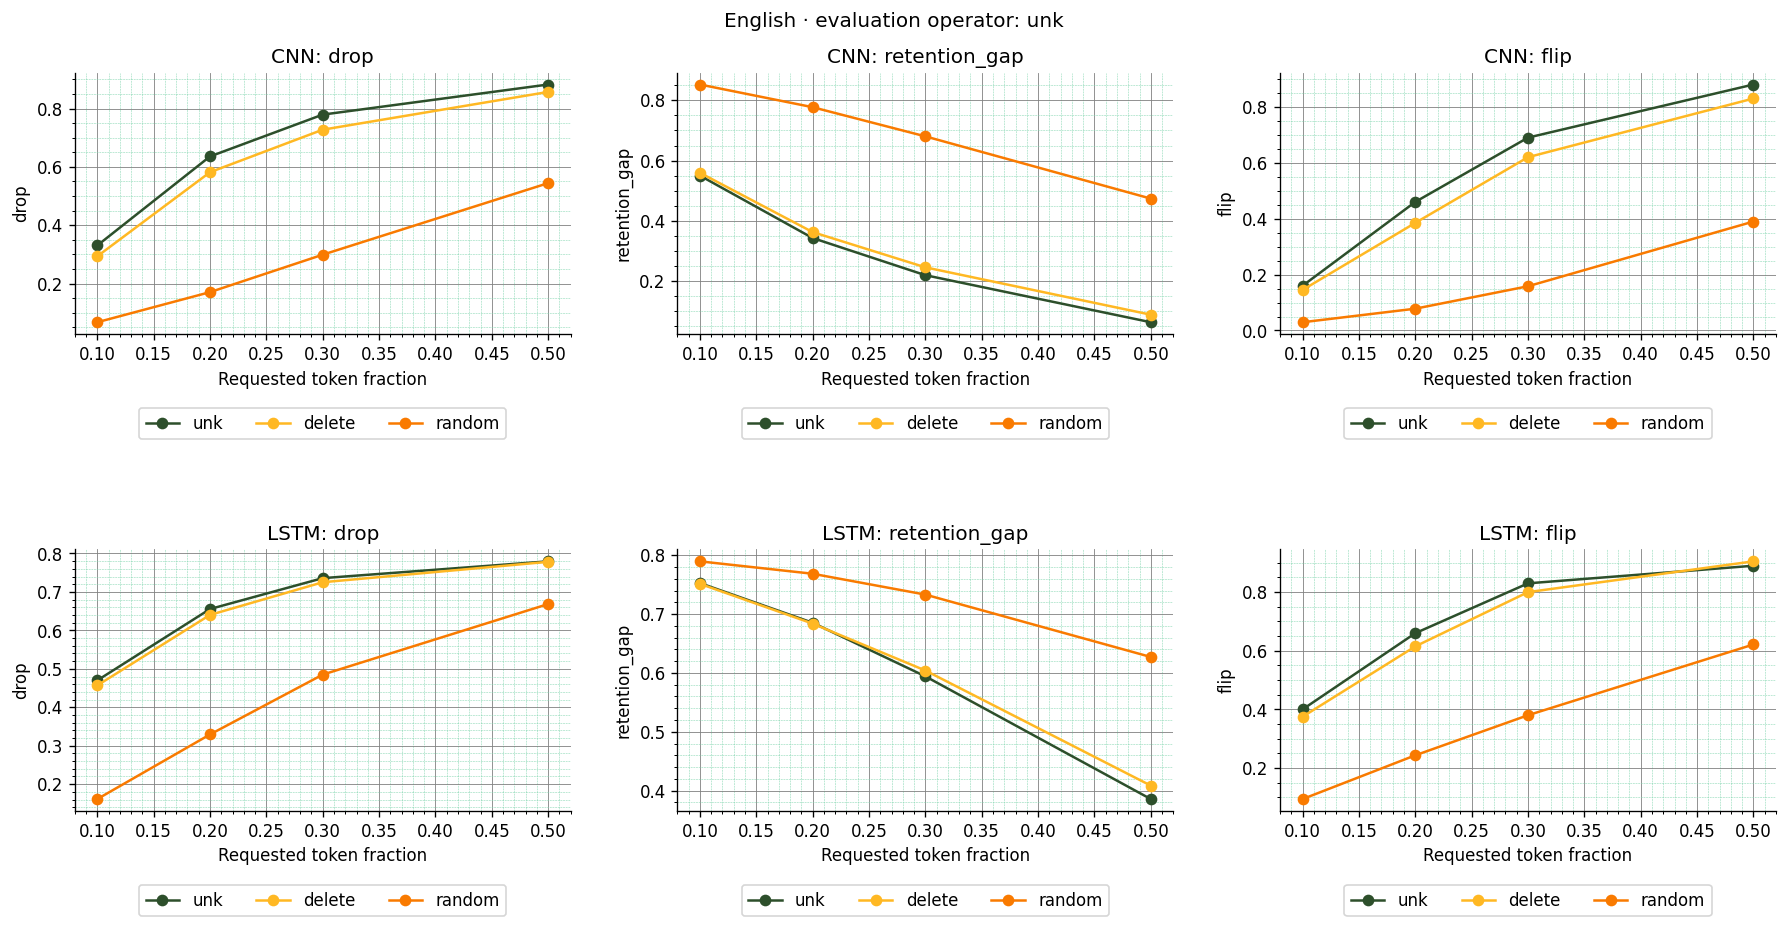

In [117]:
plot_outcomes('eng','unk')

### Explanation outcomes for eng: delete
In the following figure we are going to compare both architectures on three related explanation measures under this perturbation operator.


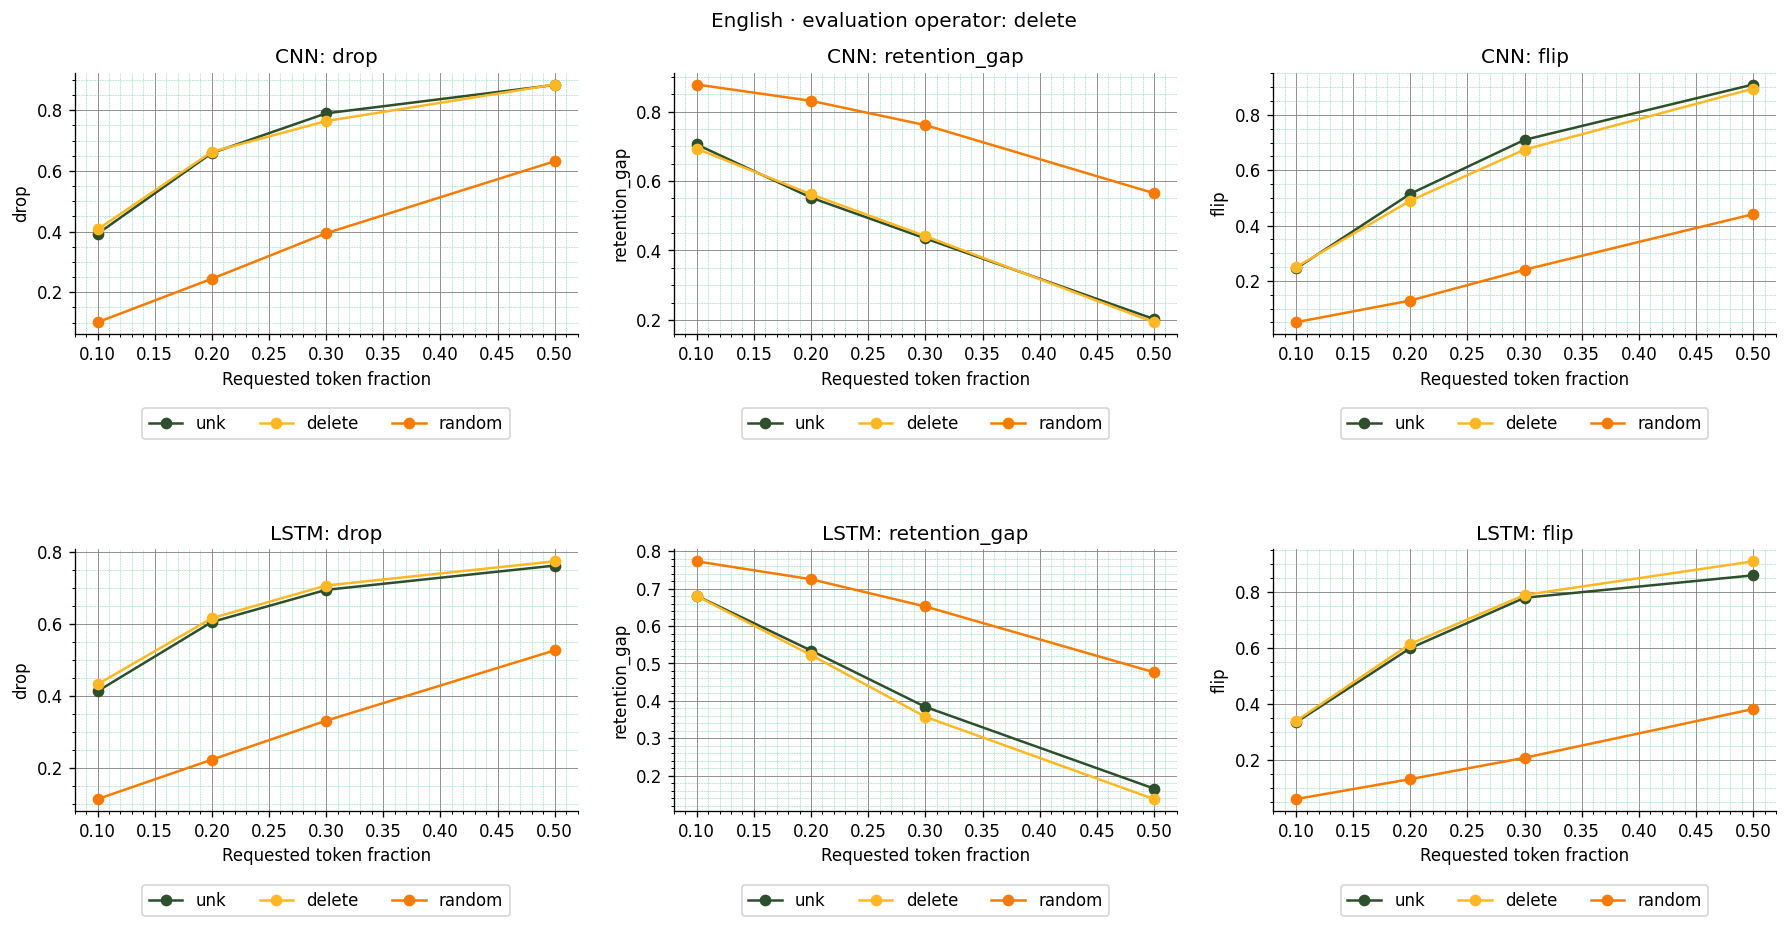

In [118]:
plot_outcomes('eng','delete')

### Explanation outcomes for xho: unk
In the following figure we are going to compare both architectures on three related explanation measures under this perturbation operator.


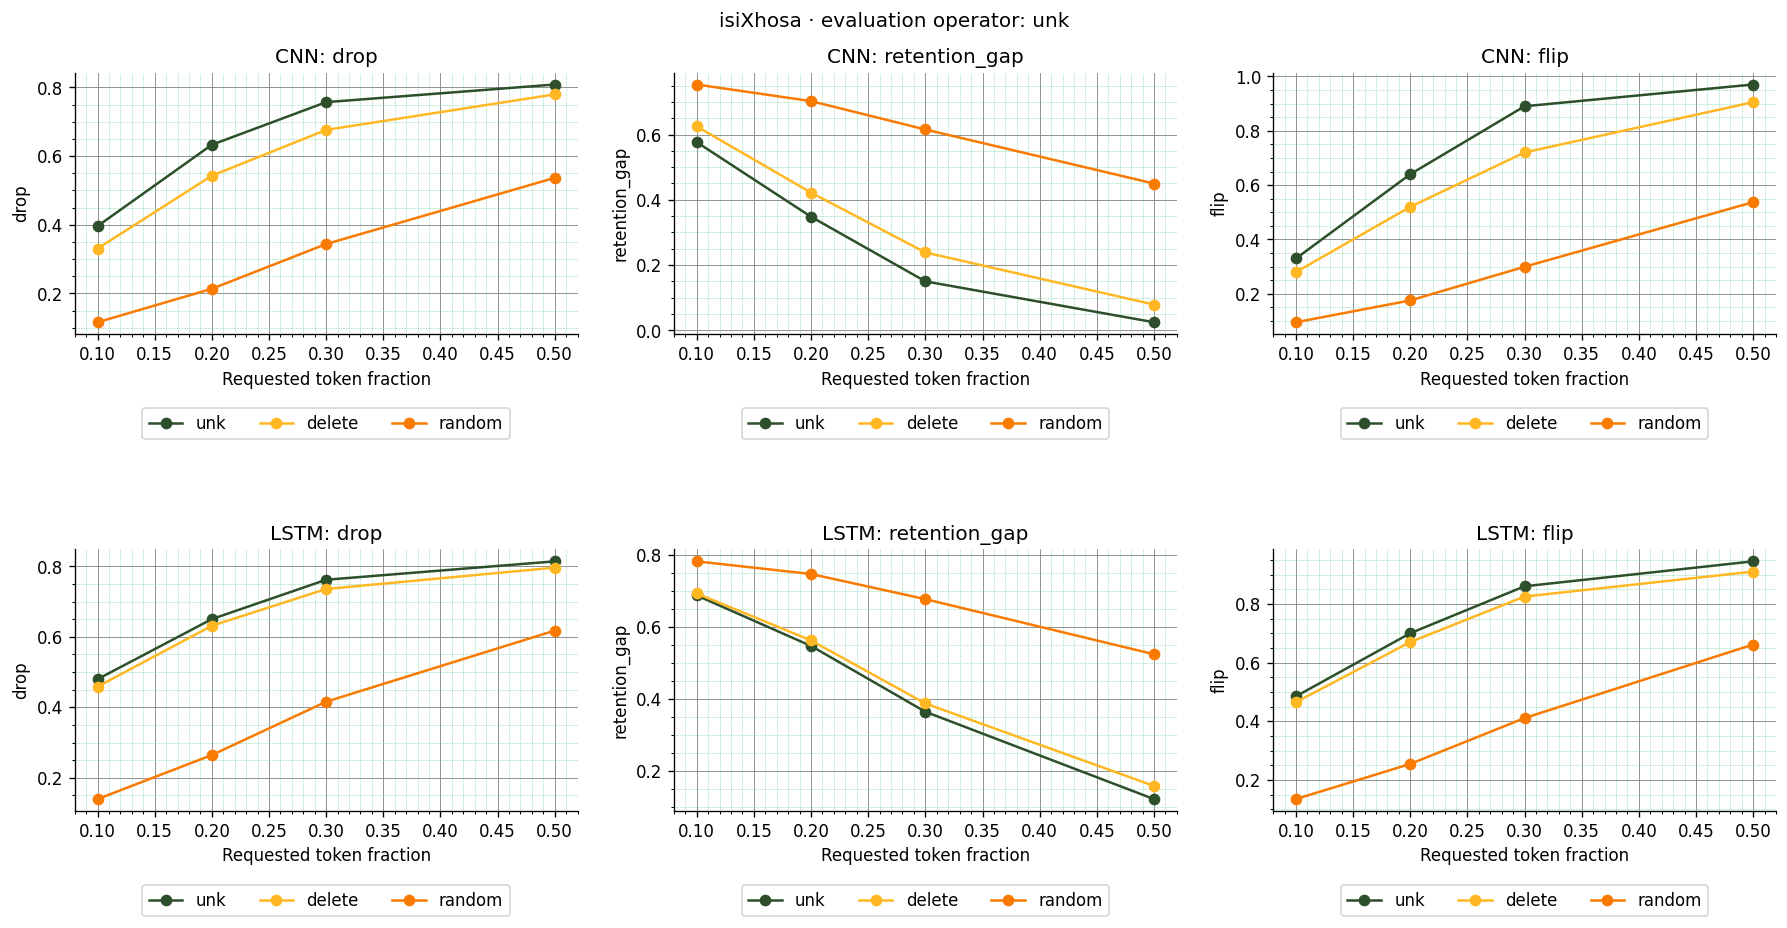

In [119]:
plot_outcomes('xho','unk')

### Explanation outcomes for xho: delete
In the following figure we are going to compare both architectures on three related explanation measures under this perturbation operator.


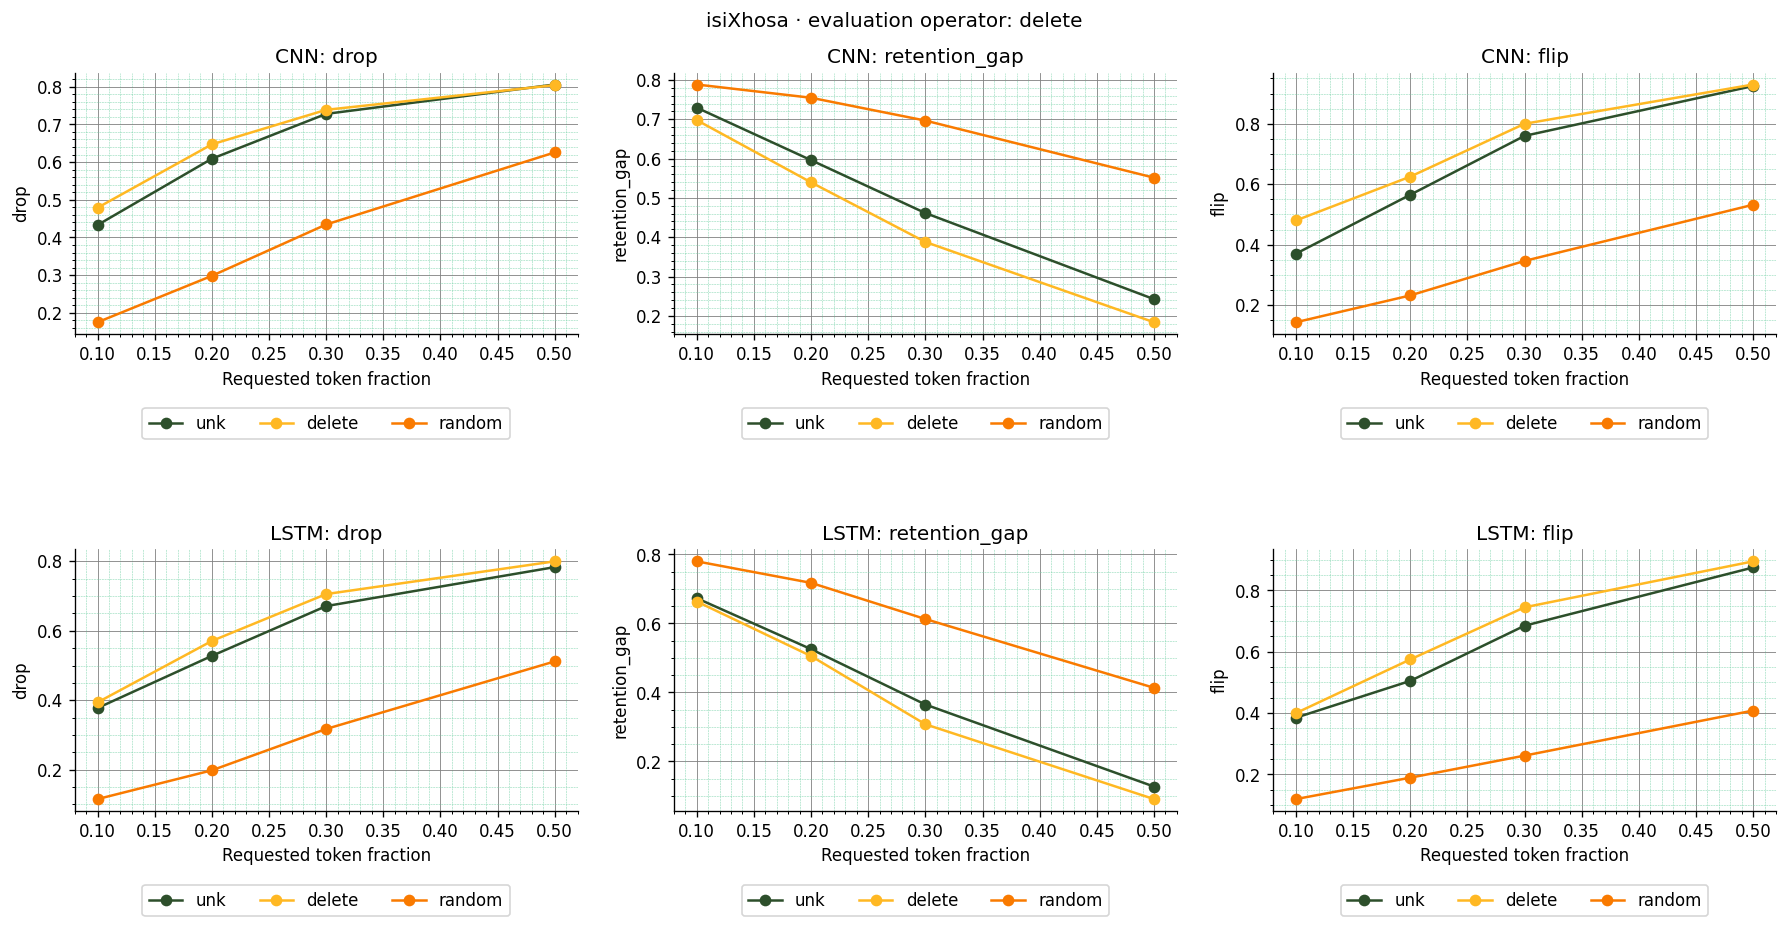

In [120]:
plot_outcomes('xho','delete')

### Explanation outcomes for zul: unk
In the following figure we are going to compare both architectures on three related explanation measures under this perturbation operator.


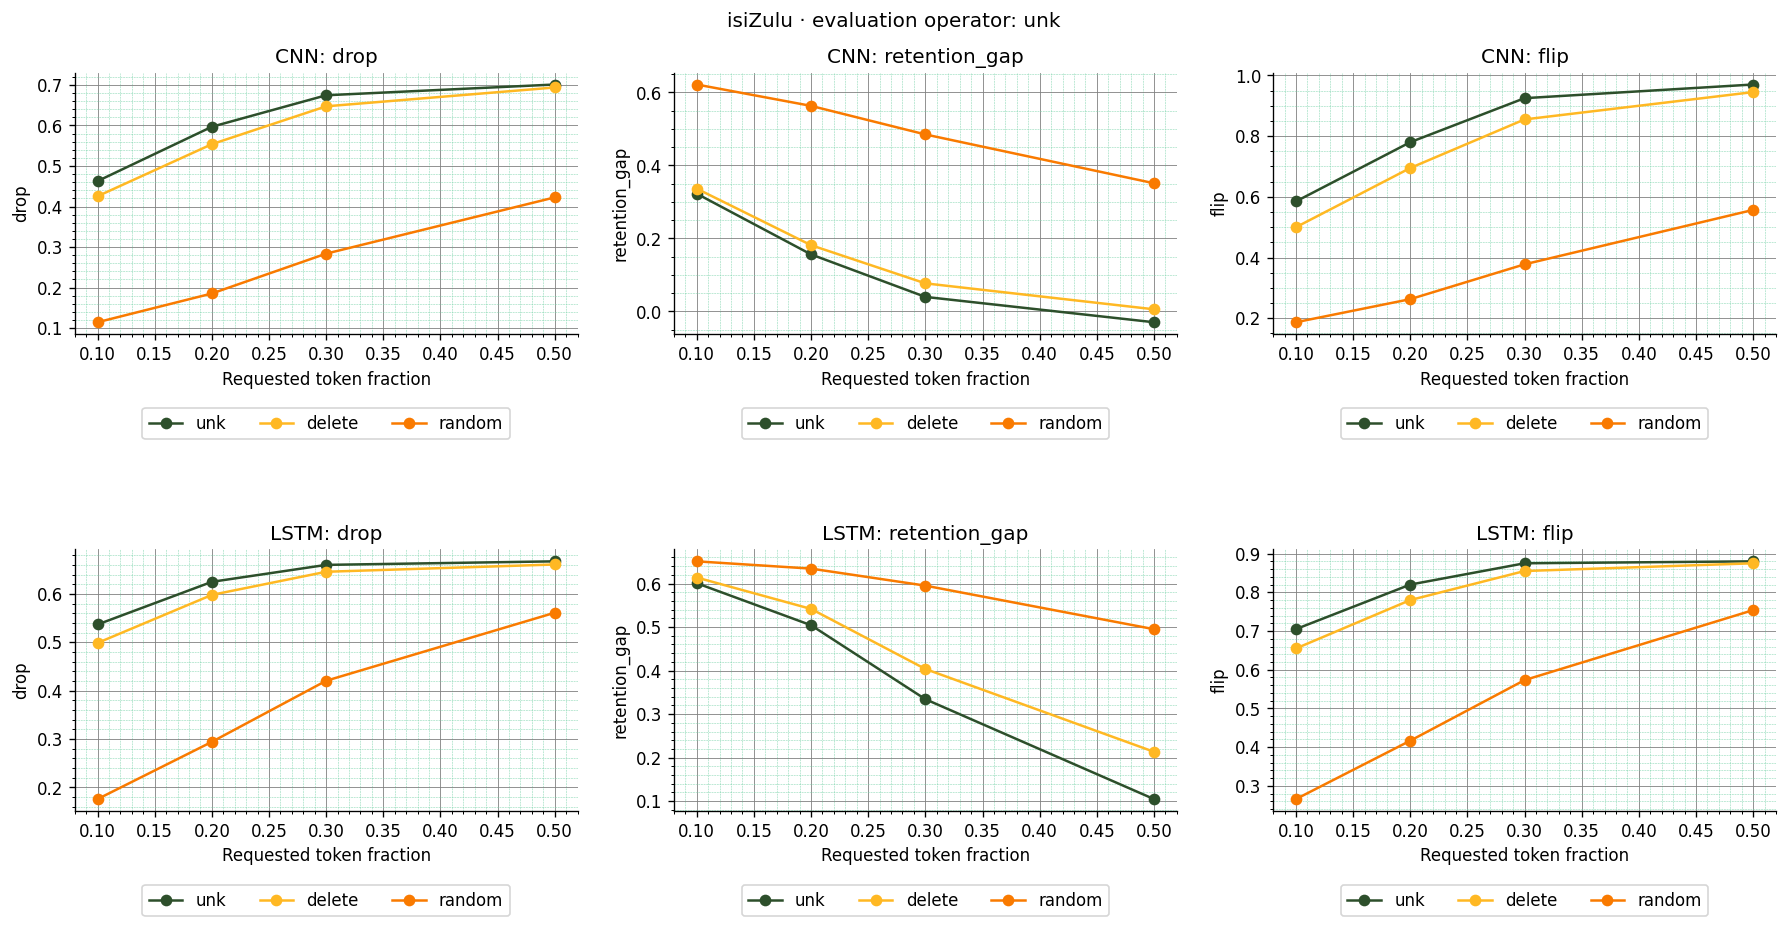

In [121]:
plot_outcomes('zul','unk')

### Explanation outcomes for zul: delete
In the following figure we are going to compare both architectures on three related explanation measures under this perturbation operator.


In [ ]:
plot_outcomes('zul','delete')

### Explanation outcomes for sot: unk
In the following figure we are going to compare both architectures on three related explanation measures under this perturbation operator.


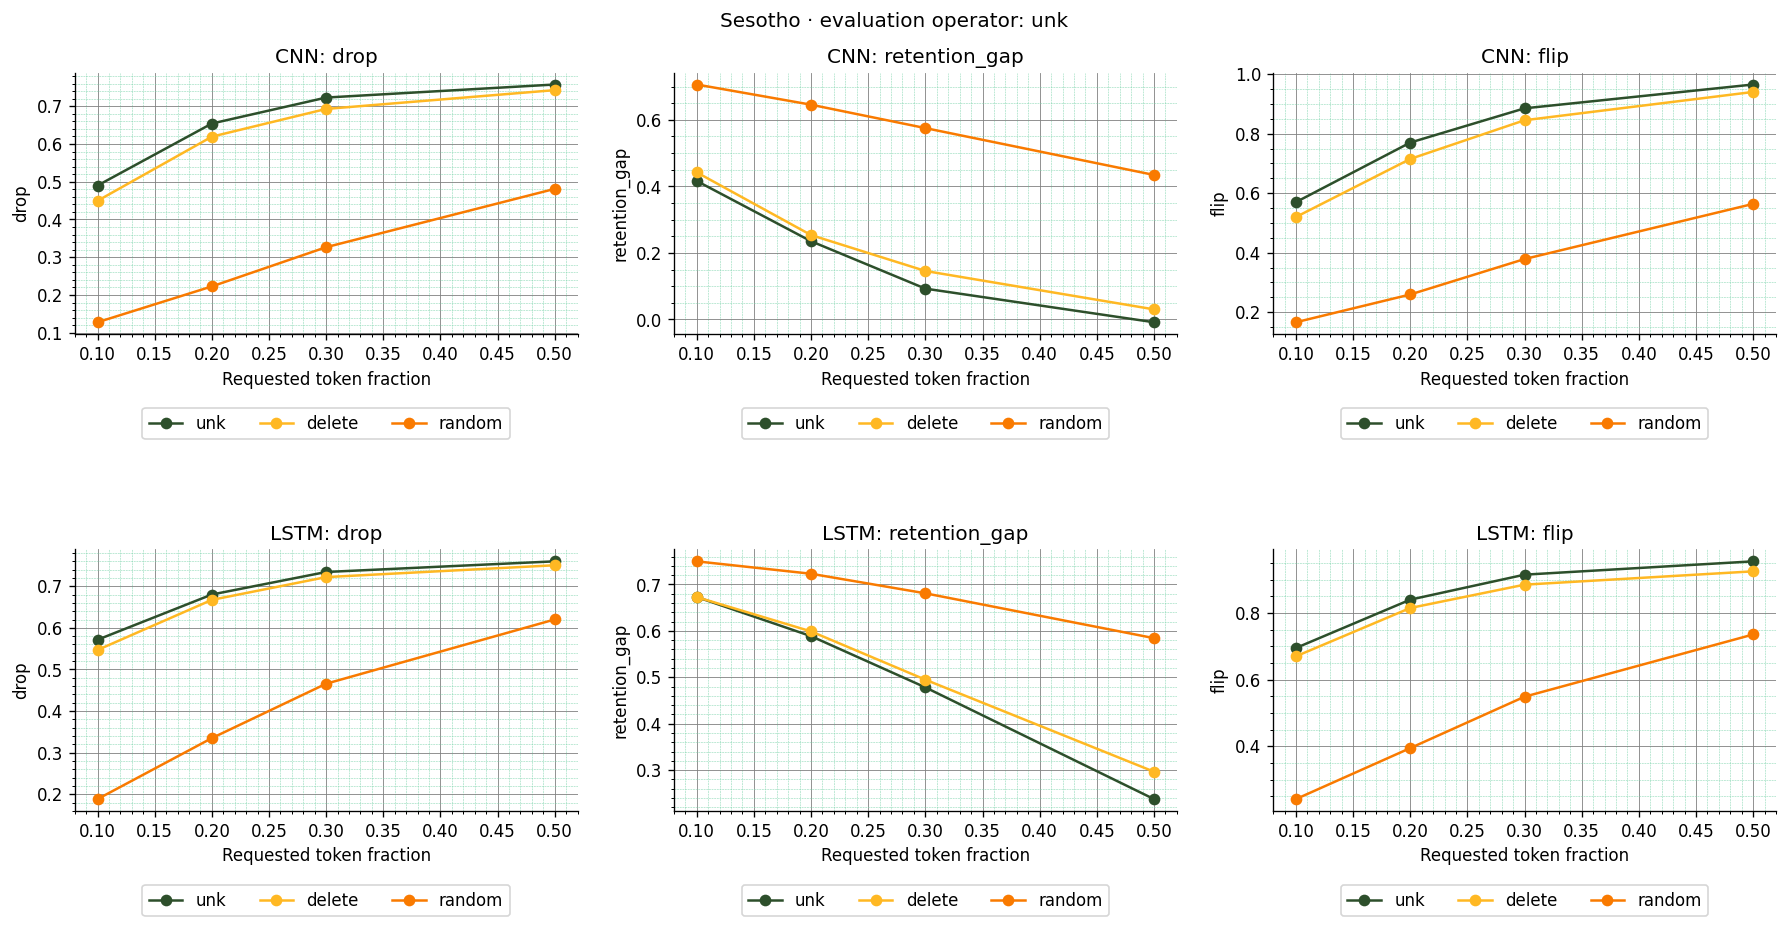

In [122]:
plot_outcomes('sot','unk')

### Explanation outcomes for sot: delete
In the following figure we are going to compare both architectures on three related explanation measures under this perturbation operator.


In [ ]:
plot_outcomes('sot','delete')

### Summarizing agreement
In the following cell we are going to summarize rank correlation, selected-token overlap and tie rates, including counts of undefined correlations.


In [123]:
keys = ['language','model','budget']
agreement_summary = operator_agreement.groupby(keys+['intent'])[['jaccard','spearman','tie_rate']].mean()
agreement_summary = agreement_summary.groupby(level=keys).mean().reset_index()
display(agreement_summary.round(4))
undefined = operator_agreement.groupby(keys).spearman.apply(lambda s:int(s.isna().sum()))
display(undefined.rename('undefined_correlations').reset_index())
agreement_summary.to_csv(OUT / 'operator_agreement_summary.csv',index=False)

,language,model,budget,jaccard,spearman,tie_rate
0,eng,CNN,0.1,0.7100,0.7831,0.0048
1,eng,CNN,0.2,0.6615,0.7831,0.0048
2,eng,CNN,0.3,0.6412,0.7831,0.0048
3,eng,CNN,0.5,0.7168,0.7831,0.0048
4,eng,LSTM,0.1,0.7883,0.8381,0.0044
5,eng,LSTM,0.2,0.7358,0.8381,0.0044
6,eng,LSTM,0.3,0.7353,0.8381,0.0044
7,eng,LSTM,0.5,0.7273,0.8381,0.0044
8,sot,CNN,0.1,0.6933,0.7705,0.0123
9,sot,CNN,0.2,0.6452,0.7705,0.0123


,language,model,budget,undefined_correlations
0,eng,CNN,0.1,0
1,eng,CNN,0.2,0
2,eng,CNN,0.3,0
3,eng,CNN,0.5,0
4,eng,LSTM,0.1,0
5,eng,LSTM,0.2,0
6,eng,LSTM,0.3,0
7,eng,LSTM,0.5,0
8,sot,CNN,0.1,0
9,sot,CNN,0.2,0


### Plotting agreement across languages
In the following figure we are going to examine selected-token overlap for all four languages. The panels are arranged in three columns with unused positions hidden.


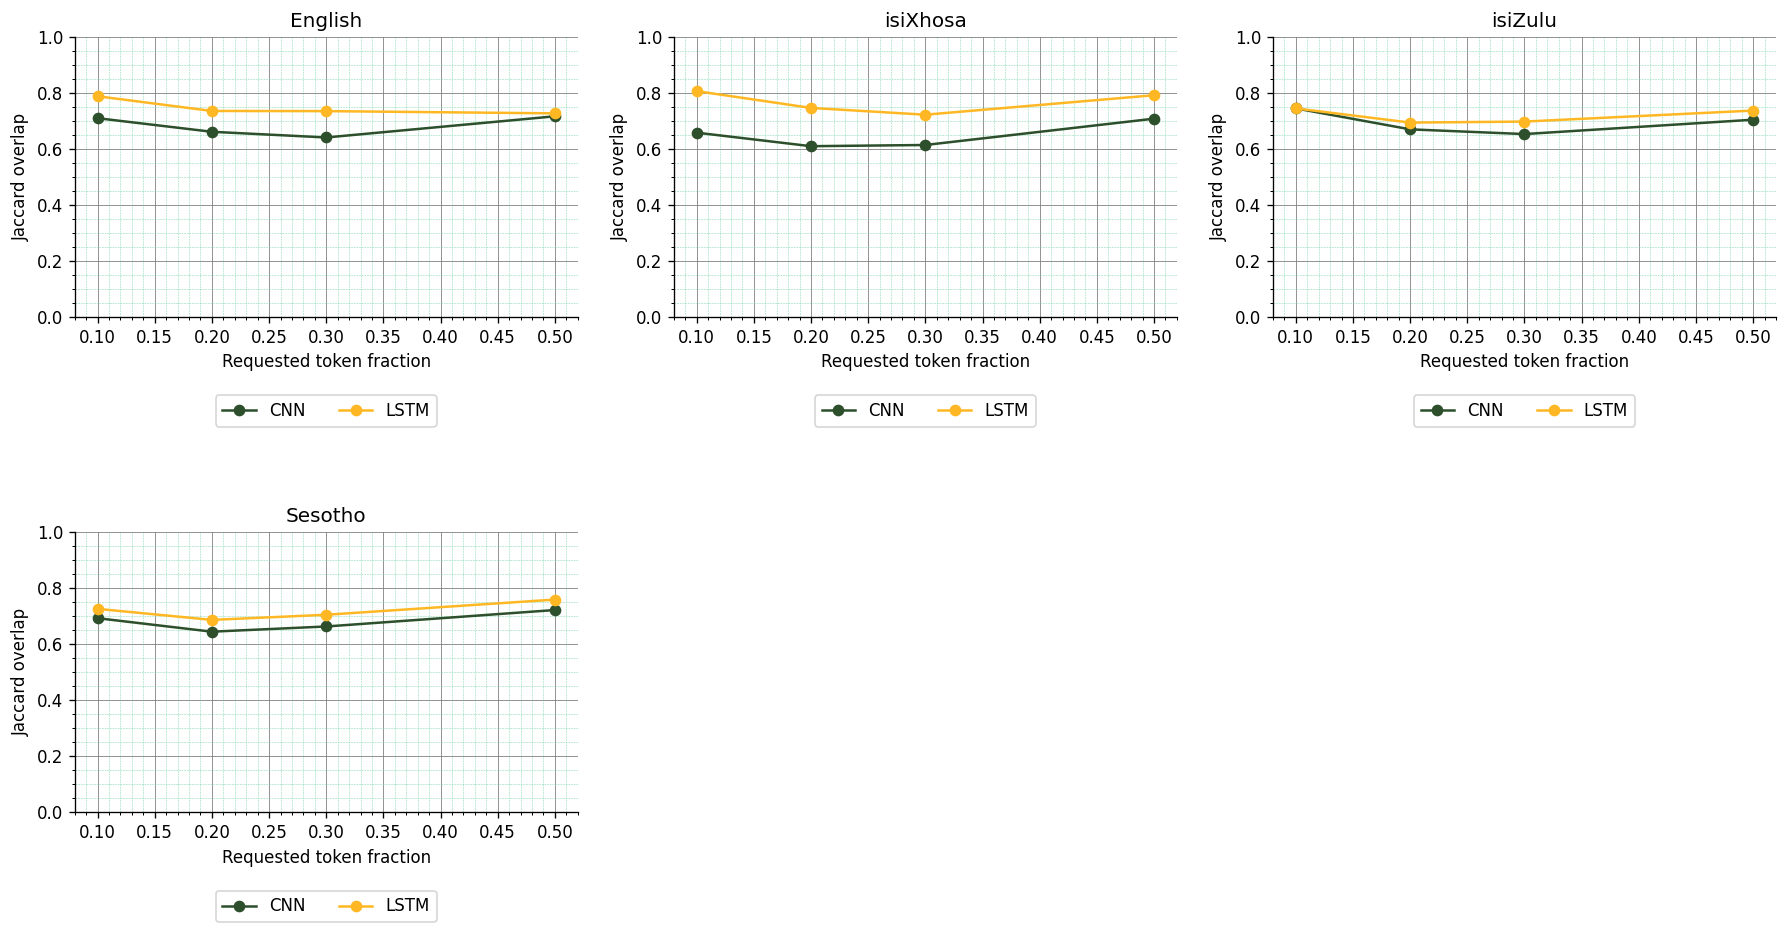

In [124]:
fig,axes = panels(4)
for ax,lang in zip(axes,LANGUAGES):
    for j,name in enumerate(MODEL_NAMES):
        line = agreement_summary[(agreement_summary.language==lang)&(agreement_summary.model==name)]
        ax.plot(line.budget,line.jaccard,marker='o',label=name,color=NATURE[j*2])
    ax.set(title=LANGUAGES[lang],xlabel='Requested token fraction',ylabel='Jaccard overlap',ylim=(0,1))
finish(fig,'operator_agreement')

### Correct and incorrect predictions
In the following cell we are going to summarize explanation behavior separately for correct and incorrect original predictions. The groups can differ in confidence, intent coverage and difficulty, so these are descriptive comparisons rather than evidence that explanation quality causes correctness.


In [125]:
subgroup = evaluation.groupby(GROUPS+['correct','intent'])[METRICS].mean().reset_index()
subgroup = subgroup.groupby(GROUPS+['correct'])[METRICS].mean().reset_index()
subgroup.to_csv(OUT / 'correct_error_macro_summary.csv',index=False)
display(subgroup[subgroup.budget==0.2].round(4))


,language,model,ranking,operator,budget,correct,drop,retention_gap,flip
2,eng,CNN,delete,delete,0.2,False,0.3467,0.3258,0.8750
3,eng,CNN,delete,delete,0.2,True,0.6747,0.5746,0.4738
10,eng,CNN,delete,unk,0.2,False,0.3493,0.2182,0.8750
11,eng,CNN,delete,unk,0.2,True,0.5914,0.3713,0.3688
18,eng,CNN,random,delete,0.2,False,0.1895,0.3731,0.5375
...,...,...,...,...,...,...,...,...,...
363,zul,LSTM,random,unk,0.2,True,0.3973,0.8157,0.4428
370,zul,LSTM,unk,delete,0.2,False,0.4541,0.4082,0.8574
371,zul,LSTM,unk,delete,0.2,True,0.6495,0.5178,0.7105
378,zul,LSTM,unk,unk,0.2,False,0.3524,0.1926,0.6922


### Plotting correct/error differences
In the following figure we are going to compare the two correctness groups using UNK-derived rankings evaluated by deletion at a 20% budget. The three columns contain the related sensitivity measures. Missing groups remain missing rather than becoming zero.


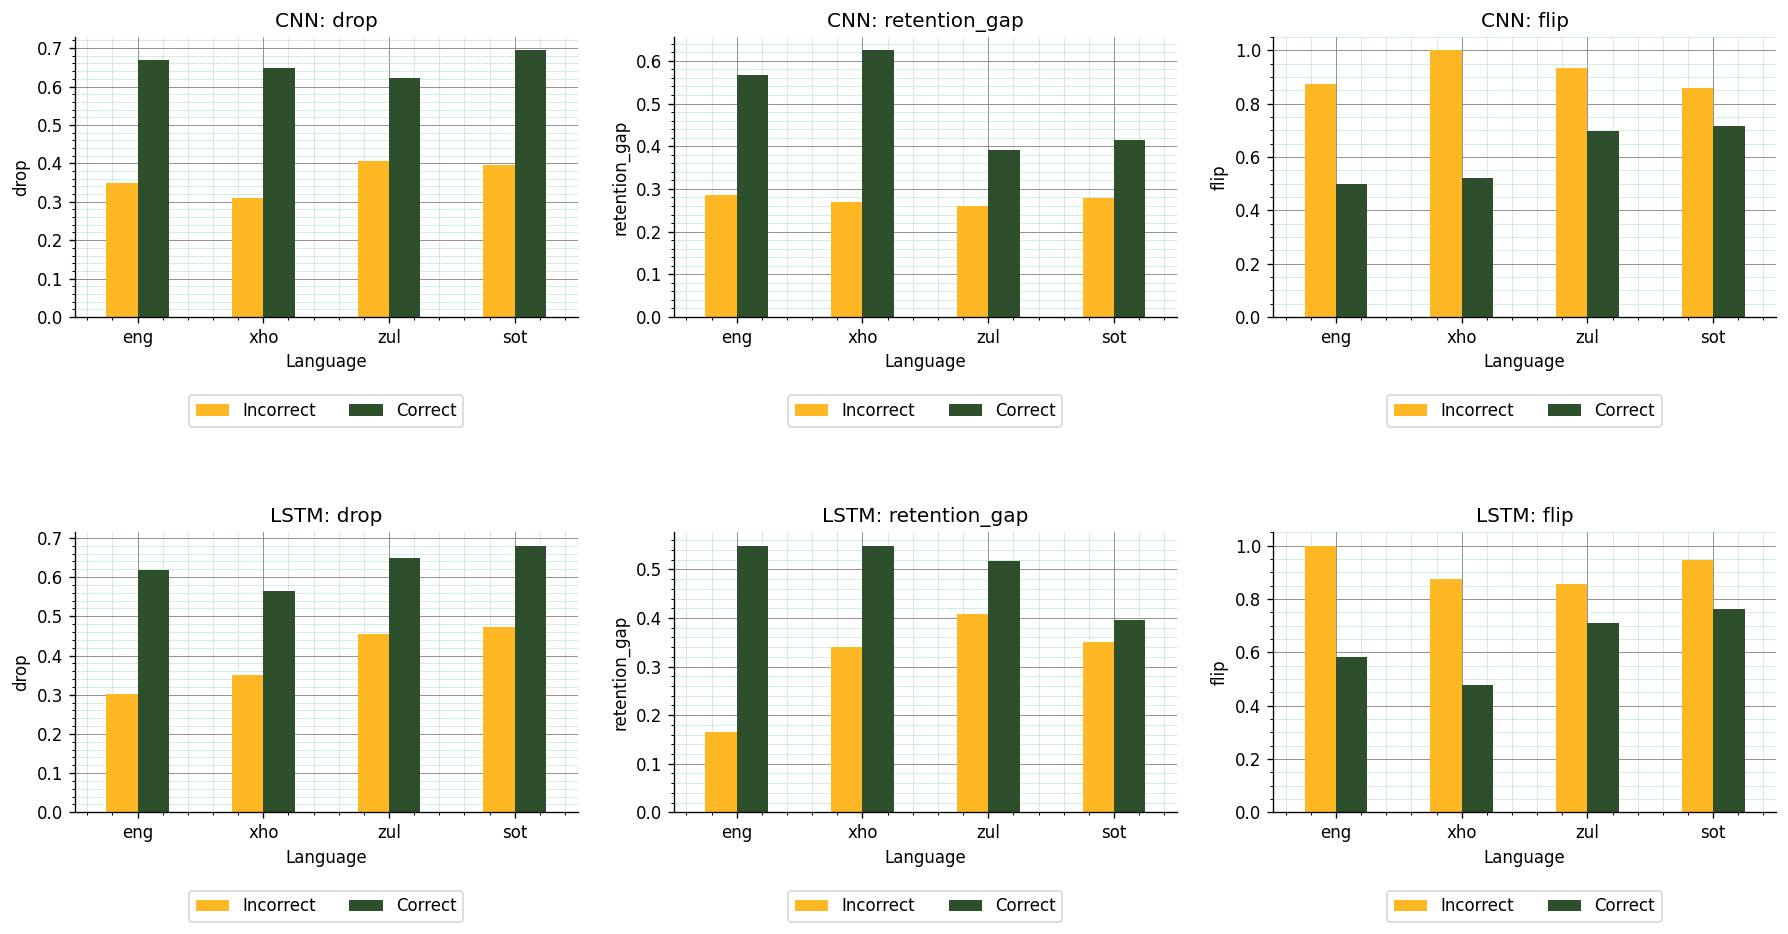

In [126]:
view = subgroup[(subgroup.budget==0.2)&(subgroup.ranking=='unk')&(subgroup.operator=='delete')]
fig,axes = panels(6)
for row,name in enumerate(MODEL_NAMES):
    for col,metric in enumerate(['drop','retention_gap','flip']):
        table = view[view.model==name].pivot(index='language',columns='correct',values=metric)
        table = table.reindex(index=LANGUAGES,columns=[False,True])
        table.columns = ['Incorrect','Correct']
        table.plot.bar(ax=axes[row*3+col],rot=0,color=[NATURE[2],NATURE[0]])
        axes[row*3+col].set(title=f'{name}: {metric}',xlabel='Language',ylabel=metric)
finish(fig,'correct_error_comparison')

### Examining individual token scores
In the following cells we are going to select the first sampled example in each language, architecture and correctness group. This predetermined rule avoids choosing examples because their explanations look convincing. The examples illustrate token sensitivity; no human explanation labels or language-expert validation are assumed.

In [127]:
representatives = examples.sort_values('example_id').groupby(['language','model','correct']).head(1)
representatives.to_csv(OUT / 'representative_examples.csv',index=False)
display(representatives[['language','model','example_id','intent','predicted_intent','correct']])

,language,model,example_id,intent,predicted_intent,correct
14400,xho,LSTM,2,alarm,alarm,True
0,eng,CNN,2,alarm,alarm,True
19200,zul,CNN,2,alarm,alarm,True
33600,sot,LSTM,2,alarm,alarm,True
4800,eng,LSTM,2,alarm,alarm,True
28800,sot,CNN,2,alarm,alarm,True
24000,zul,LSTM,2,alarm,alarm,True
9600,xho,CNN,2,alarm,alarm,True
33720,sot,LSTM,18,balance,transactions,False
19320,zul,CNN,18,balance,transfer,False


### Defining the token-score figure
In the following cell we are going to define three related panels for one example: UNK importance, deletion importance and their relationship. Up to fifteen positions with the largest absolute UNK score appear in the bar charts, while the scatter plot includes all retained positions. Token positions are zero-based.


In [128]:
def plot_example(selected):
    example = samples[selected.language].set_index('example_id').loc[selected.example_id]
    print('Text:',example.text,'| True:',selected.intent,'| Predicted:',selected.predicted_intent)
    all_tokens = token_scores[(token_scores.language==selected.language)&(token_scores.model==selected.model)
                             &(token_scores.example_id==selected.example_id)].copy()
    view = all_tokens.loc[all_tokens.unk_score.abs().nlargest(15).index].sort_values('position')
    fig,axes = panels(3,height=5)
    labels = [f'{p}: {t}' for p,t in zip(view.position,view.token)]
    for ax,column,title,color in zip(axes[:2],['unk_score','delete_score'],['UNK','Deletion'],[NATURE[0],NATURE[2]]):
        ax.barh(labels,view[column],color=color,label=title)
        ax.axvline(0,color=NATURE[9],linewidth=.8)
        ax.set(title=title,xlabel='Probability change')
    axes[2].scatter(all_tokens.unk_score,all_tokens.delete_score,color=NATURE[6],label='Token positions')
    axes[2].set(title='Agreement of token scores',xlabel='UNK score',ylabel='Deletion score')
    finish(fig,f'{selected.language}_{selected.model}_{selected.example_id}_token_scores')


### Token scores for eng
In the following figure we are going to inspect the first predetermined representative for this language.


Text: i need an alarm clock please | True: alarm | Predicted: alarm


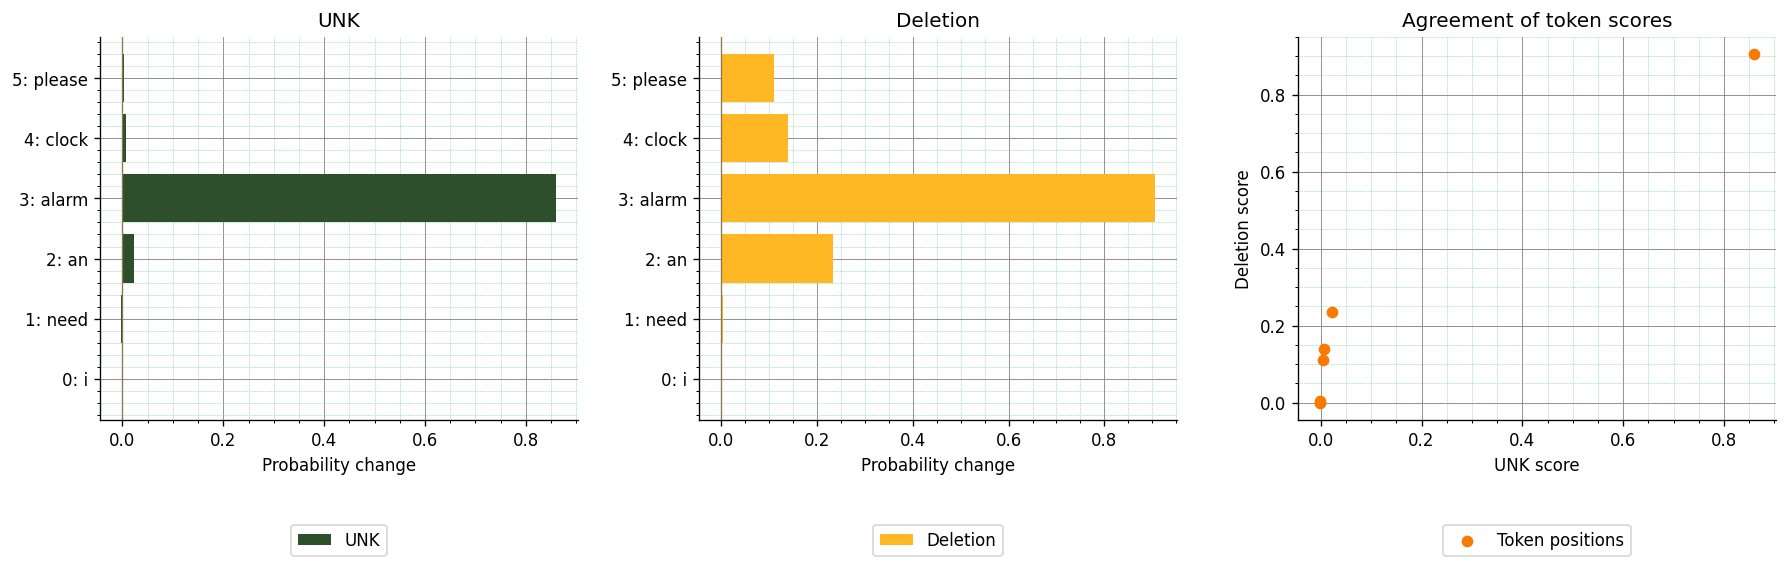

In [129]:
plot_example(representatives[representatives.language=='eng'].iloc[0])

### Token scores for xho
In the following figure we are going to inspect the first predetermined representative for this language.


Text: Seta i-alam ka-3 yangongomao ekuseni.  | True: alarm | Predicted: alarm


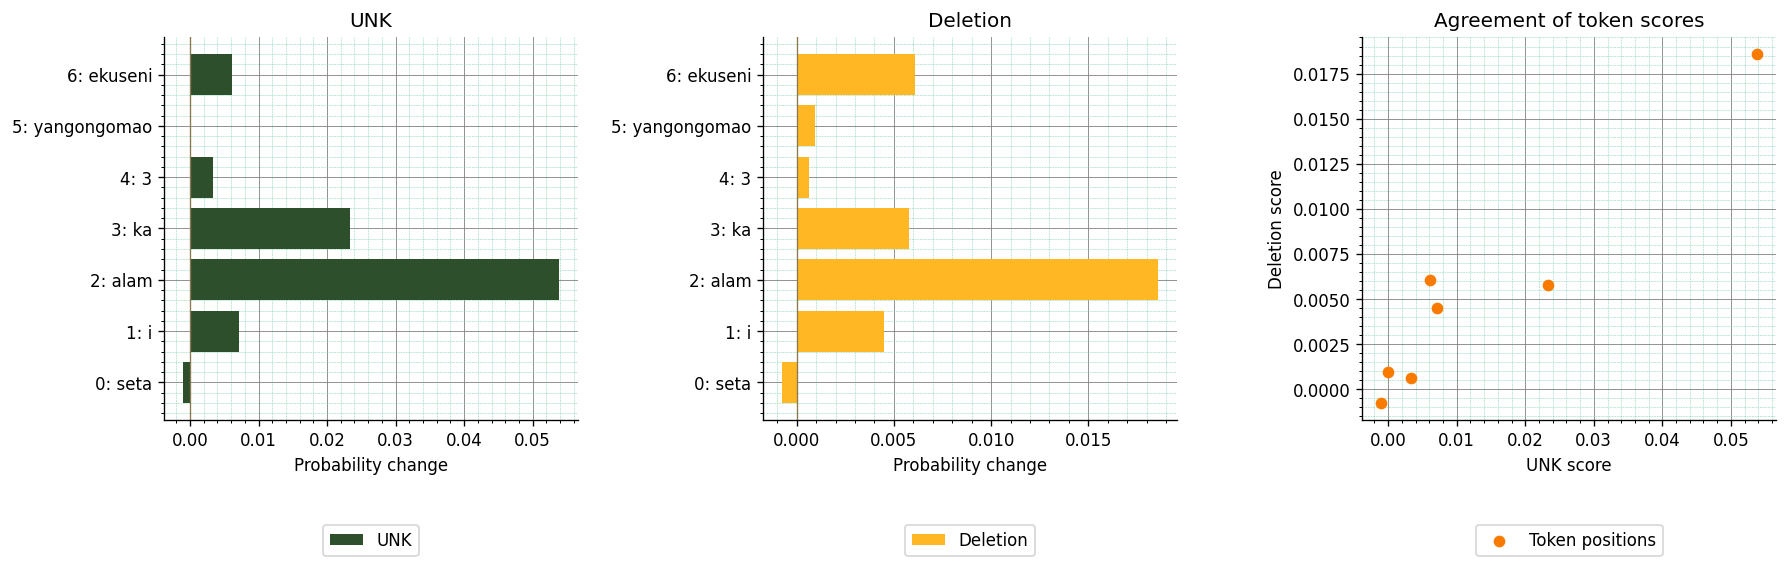

In [130]:
plot_example(representatives[representatives.language=='xho'].iloc[0])

### Token scores for zul
In the following figure we are going to inspect the first predetermined representative for this language.


Text: Ngicela ungivuse ngo-6:30 a.m. ngohlelo lokugaywa kabusha kwepulasitiki. | True: alarm | Predicted: alarm


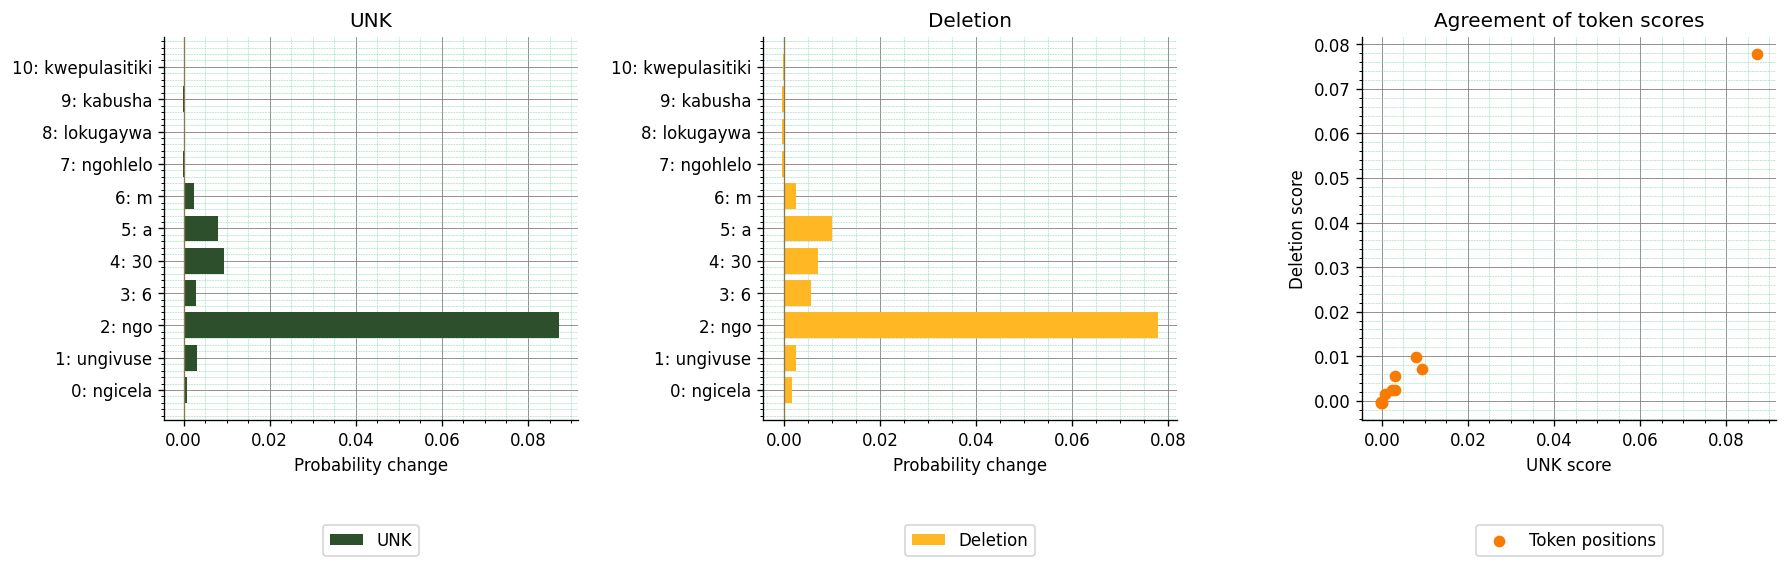

In [131]:
plot_example(representatives[representatives.language=='zul'].iloc[0])

### Token scores for sot
In the following figure we are going to inspect the first predetermined representative for this language.


Text: Ke nako e feng e maleba ya ho tsoha o rapele? | True: alarm | Predicted: alarm


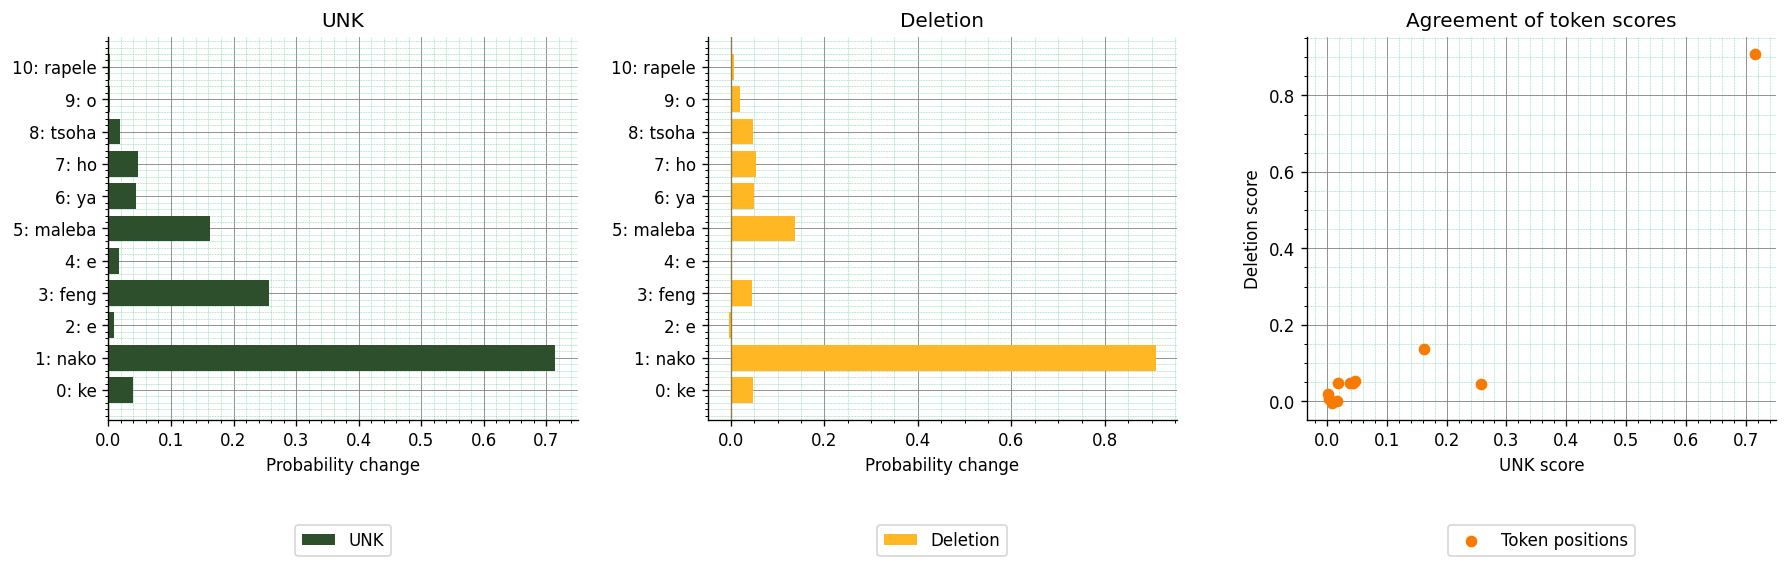

In [132]:
plot_example(representatives[representatives.language=='sot'].iloc[0])